Функции для графиков

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('boxns60000_koef1_16.9.csv')
data['kt'] = pd.to_numeric(data['kt'], errors='coerce')

# Координаты чипа
ratio = 5  # соотношение длины чипа к высоте
bias = 30  # смещение относительно левого
height = 3  # высота чипа
x_min_chip = bias
x_max_chip = bias + ratio * height
y_min_chip = 0
y_max_chip = height-1

dt = 0.1255



temperature_vmin = 0.9
temperature_vmax = 2.1
density_vmin = 0.75
density_vmax = 1.25

# Словарь для перевода
translation = {
    'temperature': 'Температура',
    'density': 'Плотность',
    'vx': 'Cкорость',
    'vy': 'Cкорость',
    'heat_flux_x': 'Поле потока тепла',
    'heat_flux_y': 'Поле потока тепла',
    'heat_flux_x_gydro': 'Поле потока тепла  с учетом гидродинамической скорости потока',
    'heat_flux_y_gydro': 'Поле потока тепла (гидро)'
}

def translate_field_name(field_name):
    return translation.get(field_name, field_name)

# Функция для заполнения значений температуры в области чипа
def fill_chip_temperature(data, x_min, x_max, y_min, y_max):
    # Маска для области внутри чипа
    chip_mask = (data['x'] > x_min) & (data['x'] < x_max) & (data['y'] >= y_min) & (data['y'] < y_max)
    data.loc[chip_mask, 'temperature'] = np.nan
    
    return data

# Функция для обнуления значений в области чипа и на периметре пространства
def nullify_regions(data, x_min_chip, x_max_chip, y_min_chip, y_max_chip, Nx, Ny):
    # Обнуление в области чипа
    chip_mask = (data['x'] >= x_min_chip) & (data['x'] <= x_max_chip) & (data['y'] >= y_min_chip) & (data['y'] <= y_max_chip)
    
    # Обнуление на периметре пространства
    perimeter_mask = (data['x'] == 0) | (data['x'] == Nx) | (data['y'] == 0) | (data['y'] == Ny)
    
    # Объединение масок
    combined_mask = chip_mask | perimeter_mask
    
    # Применение маски
    data.loc[combined_mask, ['vx', 'vy', 'heat_flux_x', 'heat_flux_y']] = 0
    return data

# Функция для заполнения NaN значениями плотности в области чипа
def nullify_chip_density(data, x_min, x_max, y_min, y_max):
    chip_mask = (data['x'] > x_min) & (data['x'] < x_max) & (data['y'] >= y_min) & (data['y'] < y_max)
    data.loc[chip_mask, 'density'] = np.nan
    # Координаты углов чипа
    corners = [(x_min, y_min), (x_min, y_max), (x_max, y_min), (x_max, y_max)]
    
    # Заполнение углов чипа значениями NaN
    #for (x, y) in corners:
    #    data.loc[(data['x'] == x) & (data['y'] == y), 'density'] = np.nan
    return data

# Функция для построения скалярного поля
def plot_scalar_field(data, field_name, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip):
    field_data = pd.to_numeric(data[field_name], errors='coerce').values.reshape((76, 26))
    plt.figure(figsize=(18, 6))
    plt.contourf(X, Y, field_data, cmap='viridis', levels=20)  # Увеличено количество уровней до 100
    plt.colorbar(label=translate_field_name(field_name))
    plt.title(f'{translate_field_name(field_name)} при t={round((kt*dt),3)} характерного времени')
    plt.xlabel('x')
    plt.ylabel('y')
    # Очерчивание периметра чипа
    plt.plot([x_min_chip, x_max_chip], [y_min_chip, y_min_chip], 'k-')
    plt.plot([x_min_chip, x_max_chip], [y_max_chip, y_max_chip], 'k-')
    plt.plot([x_min_chip, x_min_chip], [y_min_chip, y_max_chip], 'k-')
    plt.plot([x_max_chip, x_max_chip], [y_min_chip, y_max_chip], 'k-')
    plt.show()

# Функция для заполнения плотности в углах средним арифметическим от ближайших точек
def fill_chip_density_corners(data, x_min, x_max, y_min, y_max):
    corner_coords = [
        (x_min, y_min),
        (x_min, y_max),
        (x_max, y_min),
        (x_max, y_max)
    ]
    for (x, y) in corner_coords:
        if x == x_min and y== y_min:
            neighbors = data[((data['x'] == x-1) & (data['y'] == y))|
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_density = neighbors['density'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'density'] = mean_density
        if x == x_min and y== y_max:
            neighbors = data[((data['x'] == x-1) & (data['y'] == y))|
                            ((data['x'] == x+1) & (data['y'] == y)) |
                            ((data['x'] == x) & (data['y'] == y-1)) |
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_density = neighbors['density'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'density'] = mean_density
        if x == x_max and y== y_max:
            neighbors = data[((data['x'] == x-1) & (data['y'] == y))|
                            ((data['x'] == x+1) & (data['y'] == y)) |
                            ((data['x'] == x) & (data['y'] == y-1)) |
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_density = neighbors['density'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'density'] = mean_density
        if x == x_max and y== y_min:
            neighbors = data[((data['x'] == x+1) & (data['y'] == y)) |
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_density = neighbors['density'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'density'] = mean_density
    return data
def fill_chip_temperature_corners(data, x_min, x_max, y_min, y_max):
    corner_coords = [
        (x_min, y_min),
        (x_min, y_max),
        (x_max, y_min),
        (x_max, y_max)
    ]
    for (x, y) in corner_coords:
        if x == x_min and y== y_min:
            neighbors = data[((data['x'] == x-1) & (data['y'] == y))|
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_temperature = neighbors['temperature'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'temperature'] = mean_temperature
        if x == x_min and y== y_max:
            neighbors = data[((data['x'] == x-1) & (data['y'] == y))|
                            ((data['x'] == x+1) & (data['y'] == y)) |
                            ((data['x'] == x) & (data['y'] == y-1)) |
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_temperature = neighbors['temperature'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'temperature'] = mean_temperature
        if x == x_max and y== y_max:
            neighbors = data[((data['x'] == x-1) & (data['y'] == y))|
                            ((data['x'] == x+1) & (data['y'] == y)) |
                            ((data['x'] == x) & (data['y'] == y-1)) |
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_temperature = neighbors['temperature'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'temperature'] = mean_temperature
        if x == x_max and y== y_min:
            neighbors = data[((data['x'] == x+1) & (data['y'] == y)) |
                            ((data['x'] == x) & (data['y'] == y+1))]
            mean_temperature = neighbors['temperature'].mean()
            data.loc[(data['x'] == x) & (data['y'] == y), 'temperature'] = mean_temperature
    return data    



# Функция для построения векторного поля
def plot_vector_field(data, field_names, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip, scale=None):
    vx = pd.to_numeric(data[field_names[0]], errors='coerce').values.reshape((76, 26))
    vy = pd.to_numeric(data[field_names[1]], errors='coerce').values.reshape((76, 26))
    
    # Очистка данных от NaN и inf
    mask = np.isfinite(vx) & np.isfinite(vy)
    X_masked = X[mask]
    Y_masked = Y[mask]
    vx_masked = vx[mask]
    vy_masked = vy[mask]
    
    plt.figure(figsize=(18, 6))
    if scale is not None:
        plt.quiver(X_masked, Y_masked, vx_masked, vy_masked, scale=scale)
    else:
        plt.quiver(X_masked, Y_masked, vx_masked, vy_masked)
    plt.title(f'{translate_field_name(field_names[0])}  при t={round((kt*dt),3)} характерного времени')
    plt.xlabel('x')
    plt.ylabel('y')
    # Очерчивание периметра чипа
    plt.plot([x_min_chip, x_max_chip], [y_min_chip, y_min_chip], 'k-')
    plt.plot([x_min_chip, x_max_chip], [y_max_chip, y_max_chip], 'k-')
    plt.plot([x_min_chip, x_min_chip], [y_min_chip, y_max_chip], 'k-')
    plt.plot([x_max_chip, x_max_chip], [y_min_chip, y_max_chip], 'k-')
    plt.show()




График для суммарного потока тепла от чипа в область

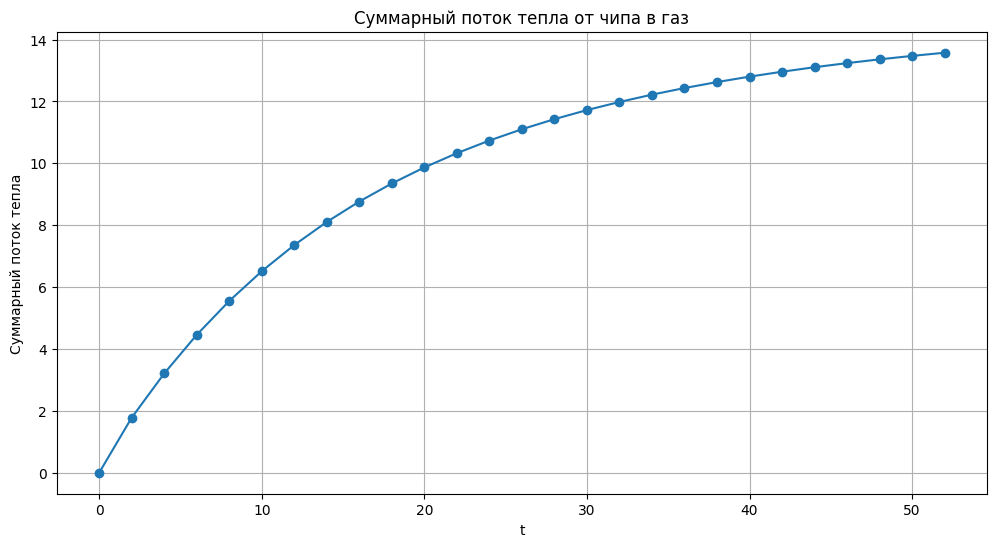

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
data = pd.read_csv('boxns60000_koef1_16.9.csv')
data['kt'] = pd.to_numeric(data['kt'], errors='coerce')

# Координаты чипа
ratio = 5  # соотношение длины чипа к высоте
bias = 30  # смещение относительно левого
height = 3  # высота чипа
x_min_chip = bias
x_max_chip = bias + ratio * height
y_min_chip = 0
y_max_chip = height

dt = 1

# Функция для суммирования теплового потока на границе чипа
def calculate_heat_flux_sum(data, x_min, x_max, y_min, y_max):
    # Границы чипа
    boundary_mask = (
        ((data['x'] == x_min) | (data['x'] == x_max)) & (data['y'] >= y_min) & (data['y'] <= y_max) |
        ((data['y'] == y_min) | (data['y'] == y_max)) & (data['x'] >= x_min) & (data['x'] <= x_max)
    )
    heat_flux_x_sum = data.loc[boundary_mask, 'heat_flux_x'].sum()
    heat_flux_y_sum = data.loc[boundary_mask, 'heat_flux_y'].sum()
    total_heat_flux_sum = np.sqrt(heat_flux_x_sum**2 + heat_flux_y_sum**2)
    return total_heat_flux_sum

# Получение уникальных значений kt
kt_values = data['kt'].unique()
kt_values.sort()

# Суммарный тепловой поток для каждого значения kt
heat_flux_sums = []

for kt in kt_values:
    data_kt = data[data['kt'] == kt]
    heat_flux_sum = calculate_heat_flux_sum(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
    heat_flux_sums.append(heat_flux_sum)

# Преобразование kt в t
t_values = kt_values * dt

# Построение графика суммарного теплового потока
plt.figure(figsize=(12, 6))
plt.plot(t_values, heat_flux_sums, marker='o')
plt.xlabel('t')
plt.ylabel('Суммарный поток тепла')
plt.title('Суммарный поток тепла от чипа в газ')
plt.grid(True)
plt.show()



График с учетом направления скорости, финальный, через периметр отстоящий на 1 точку. Предыдущий без учета размерности.

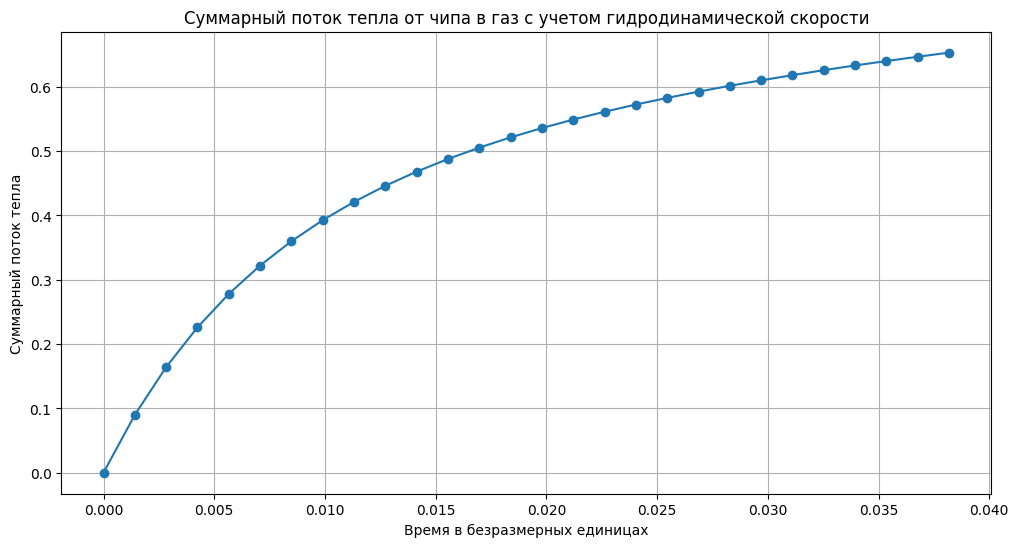

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
data = pd.read_csv('boxns60000_koef1_16.9.csv')
data['kt'] = pd.to_numeric(data['kt'], errors='coerce')

# Координаты чипа
ratio = 5  # соотношение длины чипа к высоте
bias = 30  # смещение относительно левого
height = 2  # высота чипа
x_min_chip = bias
x_max_chip = bias + ratio * height
y_min_chip = 0
y_max_chip = height

dt = 0.0005*(pow(2,0.5))

# Преобразование данных в числовой формат
data['heat_flux_x_gydro'] = pd.to_numeric(data['heat_flux_x_gydro'], errors='coerce')
data['heat_flux_y_gydro'] = pd.to_numeric(data['heat_flux_y_gydro'], errors='coerce')

# Функция для вычисления нормали к поверхности чипа с учетом направления теплового потока
def calculate_normal_and_flux_sign(x, y, x_min, x_max, y_min, y_max):
    if x == x_min - 1:
        return np.array([-1, 0])  # левая грань, положительное направление влево
    elif x == x_max + 1:
        return np.array([1, 0])  # правая грань, положительное направление вправо
    elif y == y_min - 1:
        return np.array([0, -1])  # нижняя грань, положительное направление вниз
    elif y == y_max + 1:
        return np.array([0, 1])  # верхняя грань, положительное направление вверх
    else:
        return np.array([0, 0])  # внутренние точки

# Функция для суммирования теплового потока на границе чипа с учетом направления скорости и нормали
def calculate_heat_flux_sum(data, x_min, x_max, y_min, y_max):
    heat_flux_sum = 0
    for index, row in data.iterrows():
        x, y = row['x'], row['y']
        normal = calculate_normal_and_flux_sign(x, y, x_min, x_max, y_min, y_max)
        heat_flux_vector = np.array([row['heat_flux_x_gydro'], row['heat_flux_y_gydro']])
        if np.any(normal) and np.isfinite(heat_flux_vector).all():  # Проверка, что нормаль и тепловой поток не нулевые и конечные
            flux_contribution = np.dot(heat_flux_vector, normal)
            heat_flux_sum += flux_contribution
    return heat_flux_sum

# Получение уникальных значений kt
kt_values = data['kt'].unique()
kt_values.sort()

# Суммарный тепловой поток для каждого значения kt
heat_flux_sums = []

for kt in kt_values:
    data_kt = data[data['kt'] == kt ]
    heat_flux_sum = calculate_heat_flux_sum(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip) *0.0375
    heat_flux_sums.append(heat_flux_sum)

# Преобразование kt в t
t_values = kt_values * dt

# Построение графика суммарного теплового потока
plt.figure(figsize=(12, 6))
plt.plot(t_values, heat_flux_sums, marker='o')
plt.xlabel('Время в безразмерных единицах')
plt.ylabel('Суммарный поток тепла')
plt.title('Суммарный поток тепла от чипа в газ с учетом гидродинамической скорости')
plt.grid(True)
plt.show()


Построение потоков тепла для двух  наборов данных

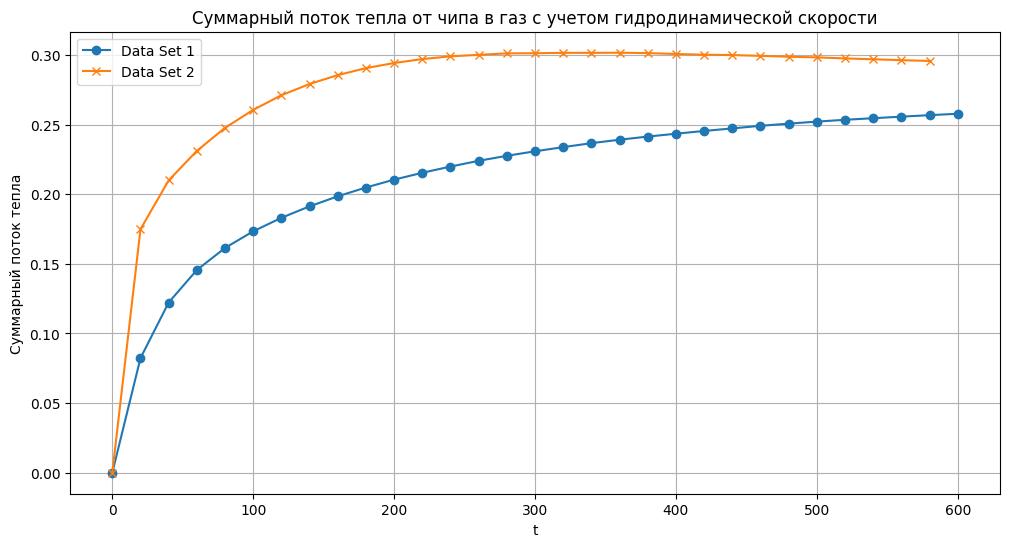

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
data1 = pd.read_csv('simulation_data_all_1606_dt05_dx2_kf16.csv')
data2 = pd.read_csv('simulation_data_all_1406_koef16.csv')
data1['kt'] = pd.to_numeric(data1['kt'], errors='coerce')
data2['kt'] = pd.to_numeric(data2['kt'], errors='coerce')

# Координаты чипа
ratio = 5  # соотношение длины чипа к высоте
bias = 30  # смещение относительно левого
height = 3  # высота чипа
x_min_chip = bias
x_max_chip = bias + ratio * height
y_min_chip = 0
y_max_chip = height

dt = 1
kt_div = 20  # Параметр для делимости
kt_limit = 600  # Лимит для kt

# Преобразование данных в числовой формат
data1['heat_flux_x_gydro'] = pd.to_numeric(data1['heat_flux_x_gydro'], errors='coerce')
data1['heat_flux_y_gydro'] = pd.to_numeric(data1['heat_flux_y_gydro'], errors='coerce')
data2['heat_flux_x_gydro'] = pd.to_numeric(data2['heat_flux_x_gydro'], errors='coerce')
data2['heat_flux_y_gydro'] = pd.to_numeric(data2['heat_flux_y_gydro'], errors='coerce')

# Функция для вычисления нормали к поверхности чипа с учетом направления теплового потока
def calculate_normal_and_flux_sign(x, y, x_min, x_max, y_min, y_max):
    if x == x_min - 1:
        return np.array([-1, 0])  # левая грань, положительное направление влево
    elif x == x_max + 1:
        return np.array([1, 0])  # правая грань, положительное направление вправо
    elif y == y_min - 1:
        return np.array([0, -1])  # нижняя грань, положительное направление вниз
    elif y == y_max + 1:
        return np.array([0, 1])  # верхняя грань, положительное направление вверх
    else:
        return np.array([0, 0])  # внутренние точки

# Функция для суммирования теплового потока на границе чипа с учетом направления скорости и нормали
def calculate_heat_flux_sum(data, x_min, x_max, y_min, y_max):
    heat_flux_sum = 0
    for index, row in data.iterrows():
        x, y = row['x'], row['y']
        normal = calculate_normal_and_flux_sign(x, y, x_min, x_max, y_min, y_max)
        heat_flux_vector = np.array([row['heat_flux_x_gydro'], row['heat_flux_y_gydro']])
        if np.any(normal) and np.isfinite(heat_flux_vector).all():  # Проверка, что нормаль и тепловой поток не нулевые и конечные
            flux_contribution = np.dot(heat_flux_vector, normal)
            heat_flux_sum += flux_contribution
    return heat_flux_sum

# Функция для вычисления и хранения теплового потока для каждого значения kt
def compute_heat_flux_sums(data):
    kt_values = data['kt'].unique()
    kt_values.sort()
    heat_flux_sums = []
    filtered_kt_values = [kt for kt in kt_values if kt % kt_div == 0 and kt <= kt_limit]
    for kt in filtered_kt_values:
        data_kt = data[data['kt'] == kt]
        heat_flux_sum = calculate_heat_flux_sum(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip) / 100
        heat_flux_sums.append(heat_flux_sum)
    return filtered_kt_values, heat_flux_sums

# Получение значений kt и суммарного теплового потока для обоих наборов данных
kt_values1, heat_flux_sums1 = compute_heat_flux_sums(data1)
kt_values2, heat_flux_sums2 = compute_heat_flux_sums(data2)

# Преобразование kt в t
t_values1 = np.array(kt_values1) * dt
t_values2 = np.array(kt_values2) * dt

# Построение графиков суммарного теплового потока на одной картинке
plt.figure(figsize=(12, 6))
plt.plot(t_values1, heat_flux_sums1, marker='o', label='Data Set 1')
plt.plot(t_values2, heat_flux_sums2, marker='x', label='Data Set 2')
plt.xlabel('t')
plt.ylabel('Суммарный поток тепла')
plt.title('Суммарный поток тепла от чипа в газ с учетом гидродинамической скорости')
plt.legend()
plt.grid(True)
plt.show()




Для разных разбиений

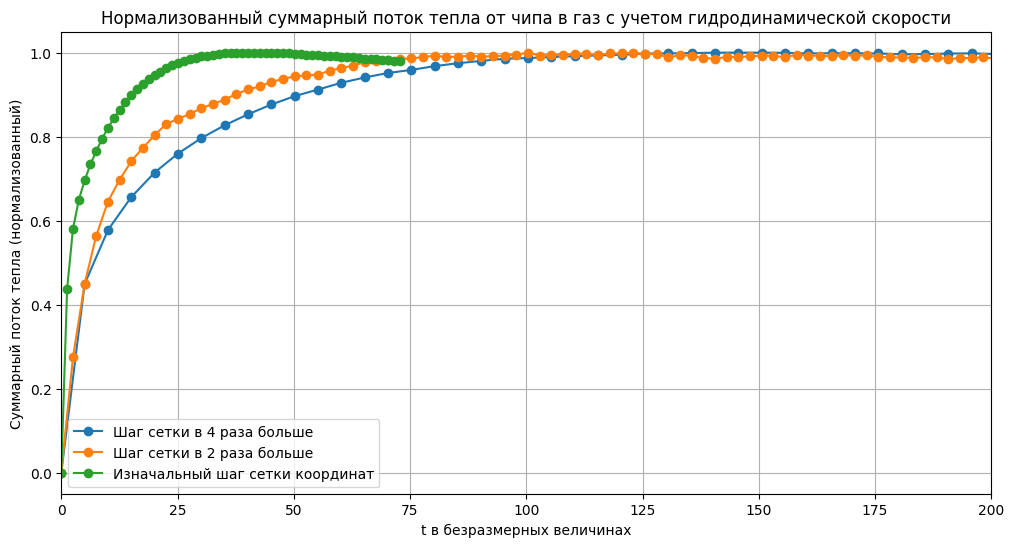

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
data1 = pd.read_csv('simulation_data_all_1606_dt025_dx4_kf16_g.csv')
data2 = pd.read_csv('simulation_data_all_1606_dt05_dx2_kf16_g.csv')
data3 = pd.read_csv('simulation_data_all_1406_koef16.csv')

# Преобразование значений 'kt' в числовой формат
for data in [data1, data2, data3]:
    data['kt'] = pd.to_numeric(data['kt'], errors='coerce')

# Координаты чипа
ratio = 5  # соотношение длины чипа к высоте
bias = 30  # смещение относительно левого
height = 3  # высота чипа
x_min_chip = bias
x_max_chip = bias + ratio * height
y_min_chip = 0
y_max_chip = height

# Временные шаги для данных
dt_data = [  0.1255*4, 0.1255*2,  0.1255]
kt_div = 8 # Параметр для делимости
kt_limit = 1000  # Лимит для kt

# Преобразование данных в числовой формат
for data in [data1, data2, data3]:
    data['heat_flux_x_gydro'] = pd.to_numeric(data['heat_flux_x_gydro'], errors='coerce')
    data['heat_flux_y_gydro'] = pd.to_numeric(data['heat_flux_y_gydro'], errors='coerce')

# Функция для вычисления нормали к поверхности чипа с учетом направления теплового потока
def calculate_normal_and_flux_sign(x, y, x_min, x_max, y_min, y_max):
    if x == x_min - 1:
        return np.array([-1, 0])  # левая грань, положительное направление влево
    elif x == x_max + 1:
        return np.array([1, 0])  # правая грань, положительное направление вправо
    elif y == y_min - 1:
        return np.array([0, -1])  # нижняя грань, положительное направление вниз
    elif y == y_max + 1:
        return np.array([0, 1])  # верхняя грань, положительное направление вверх
    else:
        return np.array([0, 0])  # внутренние точки

# Функция для суммирования теплового потока на границе чипа с учетом направления скорости и нормали
def calculate_heat_flux_sum(data, x_min, x_max, y_min, y_max):
    heat_flux_sum = 0
    for index, row in data.iterrows():
        x, y = row['x'], row['y']
        normal = calculate_normal_and_flux_sign(x, y, x_min, x_max, y_min, y_max)
        heat_flux_vector = np.array([row['heat_flux_x_gydro'], row['heat_flux_y_gydro']])
        if np.any(normal) and np.isfinite(heat_flux_vector).all():  # Проверка, что нормаль и тепловой поток не нулевые и конечные
            flux_contribution = np.dot(heat_flux_vector, normal)
            heat_flux_sum += flux_contribution
    return heat_flux_sum

# Функция для вычисления и хранения теплового потока для каждого значения kt
def compute_heat_flux_sums(data):
    kt_values = data['kt'].unique()
    kt_values.sort()
    heat_flux_sums = []
    filtered_kt_values = [kt for kt in kt_values if kt % kt_div == 0 and kt < kt_limit]
    for kt in filtered_kt_values:
        data_kt = data[data['kt'] == kt]
        heat_flux_sum = calculate_heat_flux_sum(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip) *0.0375
        heat_flux_sums.append(heat_flux_sum)
    return filtered_kt_values, heat_flux_sums

# Функция для нахождения индекса точки, где первая производная наиболее близка к единице
def find_closest_to_one_derivative(t_values, flux_sums):
    derivatives = np.gradient(flux_sums, t_values)
    index = np.argmin(np.abs(derivatives - 1))
    return t_values[index], flux_sums[index]

# Получение значений kt и суммарного теплового потока для всех наборов данных
kt_values_all = []
heat_flux_sums_all = []
t_values_all = []

for data, dt in zip([data1, data2, data3], dt_data):
    kt_values, heat_flux_sums = compute_heat_flux_sums(data)
    t_values = np.array(kt_values) * dt
    kt_values_all.append(kt_values)
    heat_flux_sums_all.append(heat_flux_sums)
    t_values_all.append(t_values)

# Нормализация данных
normalized_data = []
for t_values, heat_flux_sums in zip(t_values_all, heat_flux_sums_all):
    t_values_norm = (t_values - t_values.min()) / (t_values.max() - t_values.min())
    heat_flux_sums_norm = (heat_flux_sums - np.min(heat_flux_sums)) / (np.max(heat_flux_sums) - np.min(heat_flux_sums))
    normalized_data.append((t_values_norm, heat_flux_sums_norm))

# Нахождение точки с касательной, равной единице для каждого набора данных
closest_points = []
for t_values_norm, heat_flux_sums_norm in normalized_data:
    t_closest, flux_closest = find_closest_to_one_derivative(t_values_norm, heat_flux_sums_norm)
    closest_points.append((t_closest, flux_closest))

# Денормализация данных для отображения на графике
denormalized_points = []
for (t_closest, flux_closest), (t_values, heat_flux_sums) in zip(closest_points, zip(t_values_all, heat_flux_sums_all)):
    t_closest = t_closest * (t_values.max() - t_values.min()) + t_values.min()
    flux_closest = flux_closest * (np.max(heat_flux_sums) - np.min(heat_flux_sums)) + np.min(heat_flux_sums)
    denormalized_points.append((t_closest, flux_closest))


normalized_flux_sums_all = []
for heat_flux_sums in heat_flux_sums_all:
    heat_flux_sums_norm = (heat_flux_sums - np.min(heat_flux_sums)) / (np.max(heat_flux_sums) - np.min(heat_flux_sums))
    normalized_flux_sums_all.append(heat_flux_sums_norm)

# Построение графиков суммарного теплового потока на одной картинке с нормализацией по y
plt.figure(figsize=(12, 6))
plt.xlim(0,200)
labels = ['Шаг сетки в 4 раза больше',
          'Шаг сетки в 2 раза больше',
          'Изначальный шаг сетки координат']

for t_values, heat_flux_sums_norm, label in zip(t_values_all, normalized_flux_sums_all, labels):
    plt.plot(t_values, heat_flux_sums_norm, marker='o', label=label)

plt.xlabel('t в безразмерных величинах')
plt.ylabel('Суммарный поток тепла (нормализованный)')
plt.title('Нормализованный суммарный поток тепла от чипа в газ с учетом гидродинамической скорости')
plt.legend()
plt.grid(True)
plt.show()


Температура, плотность, скорость, поток тепла, давление

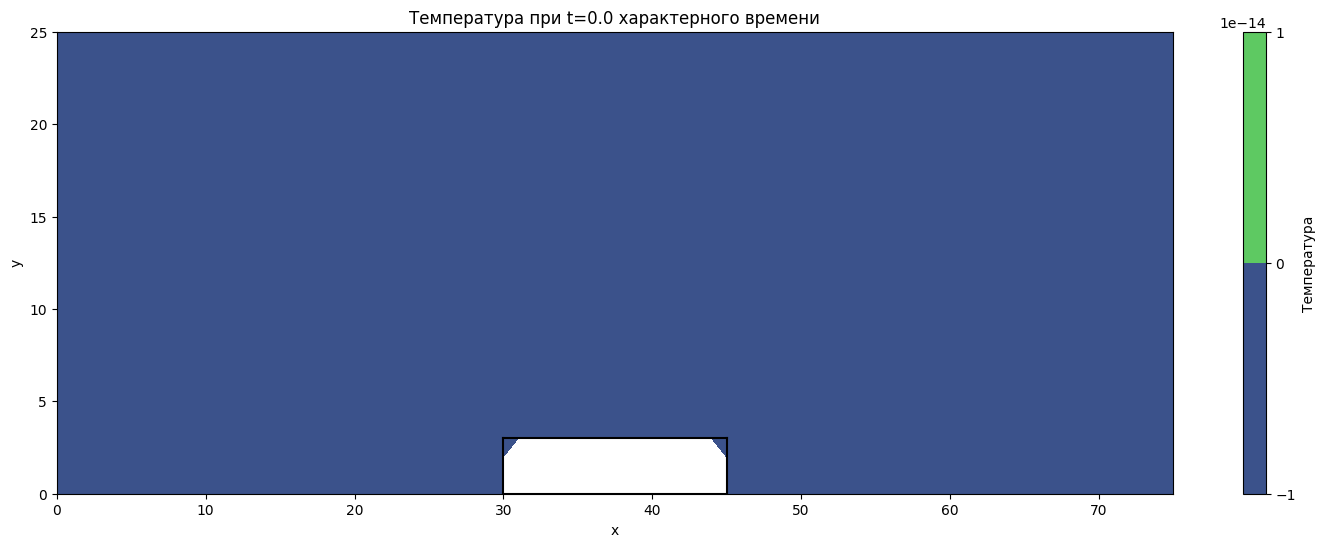

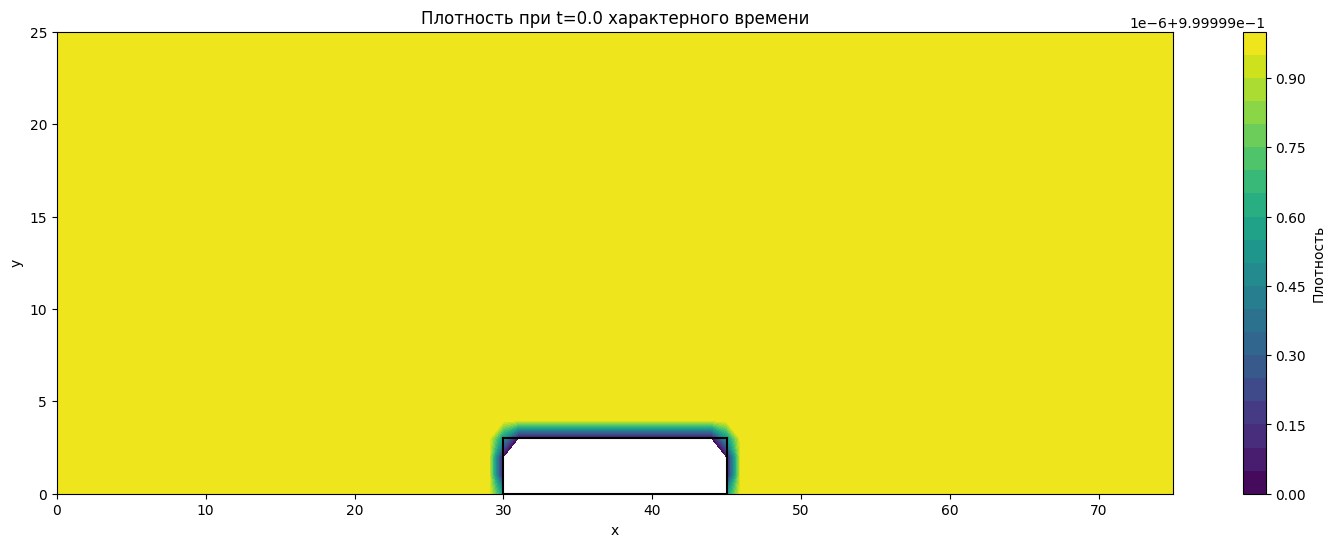

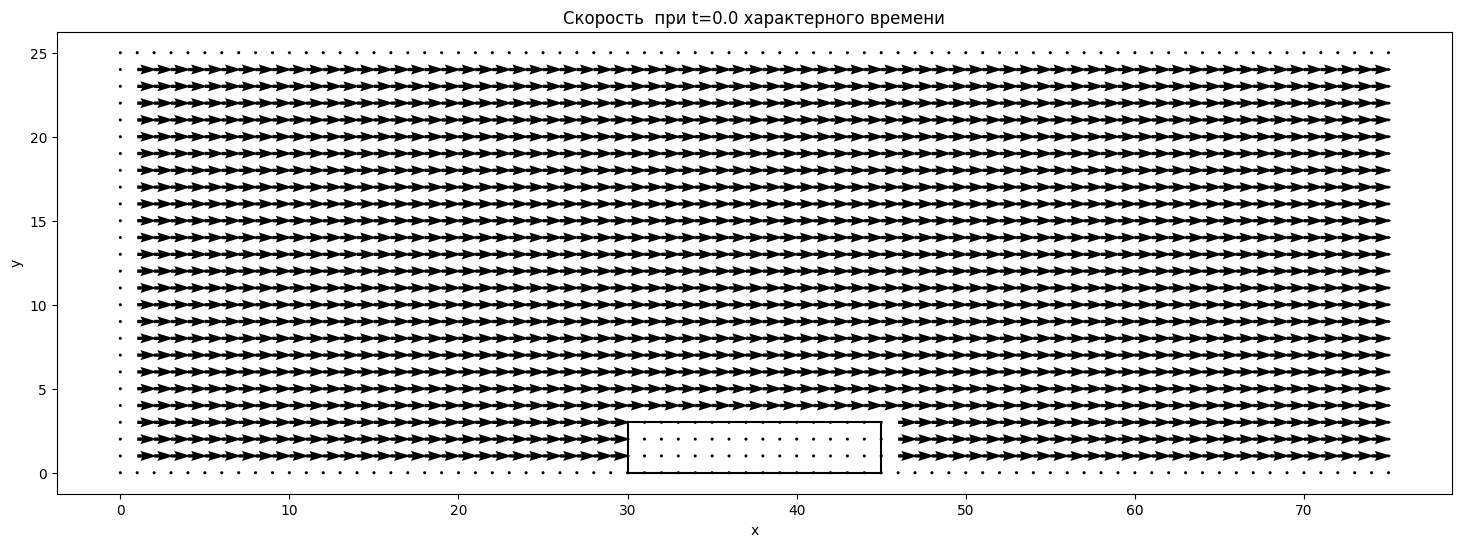

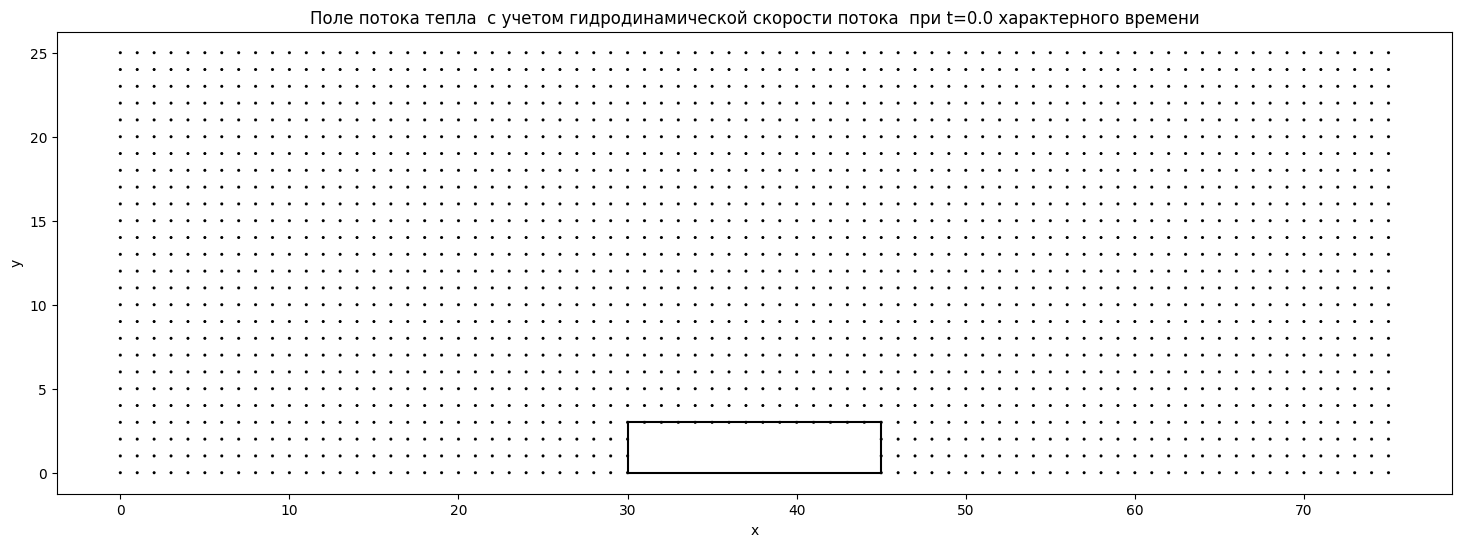

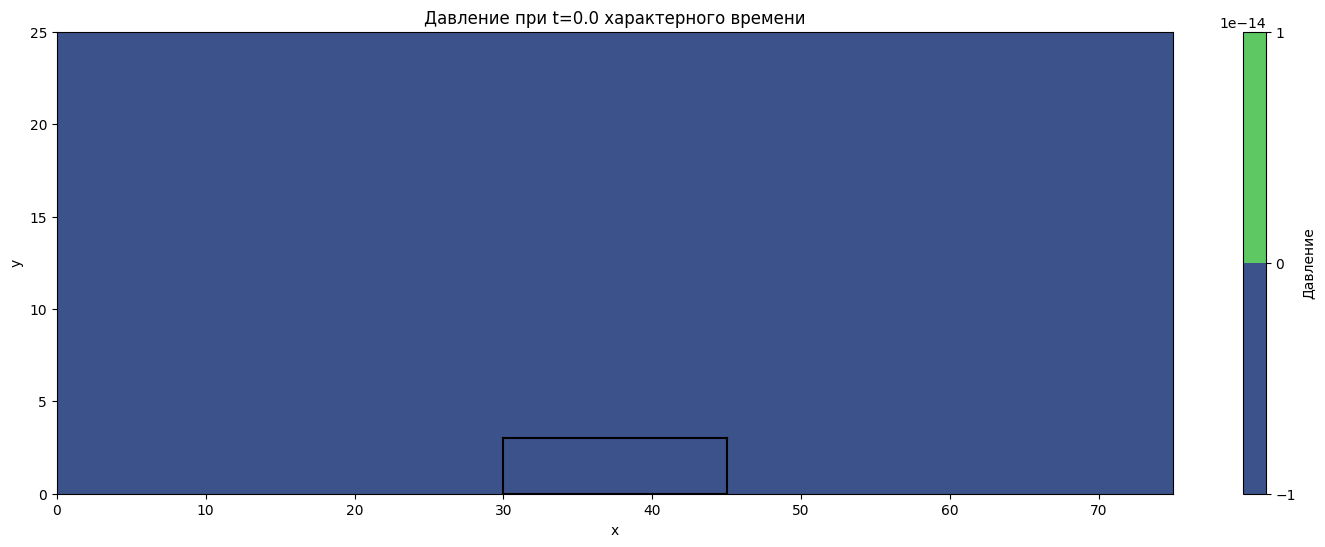

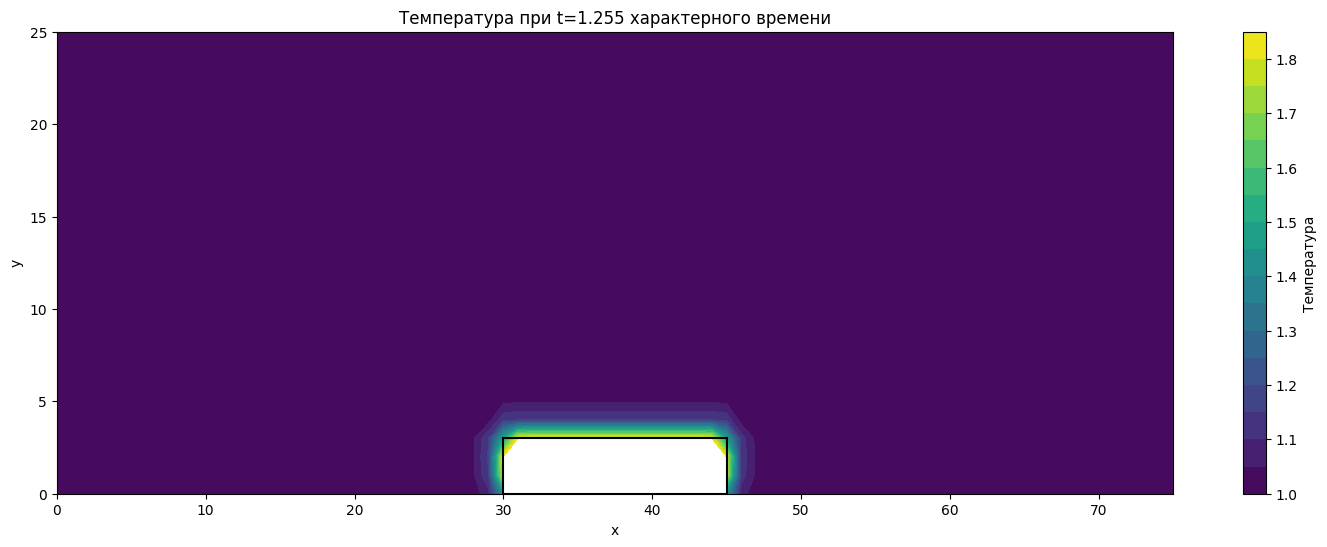

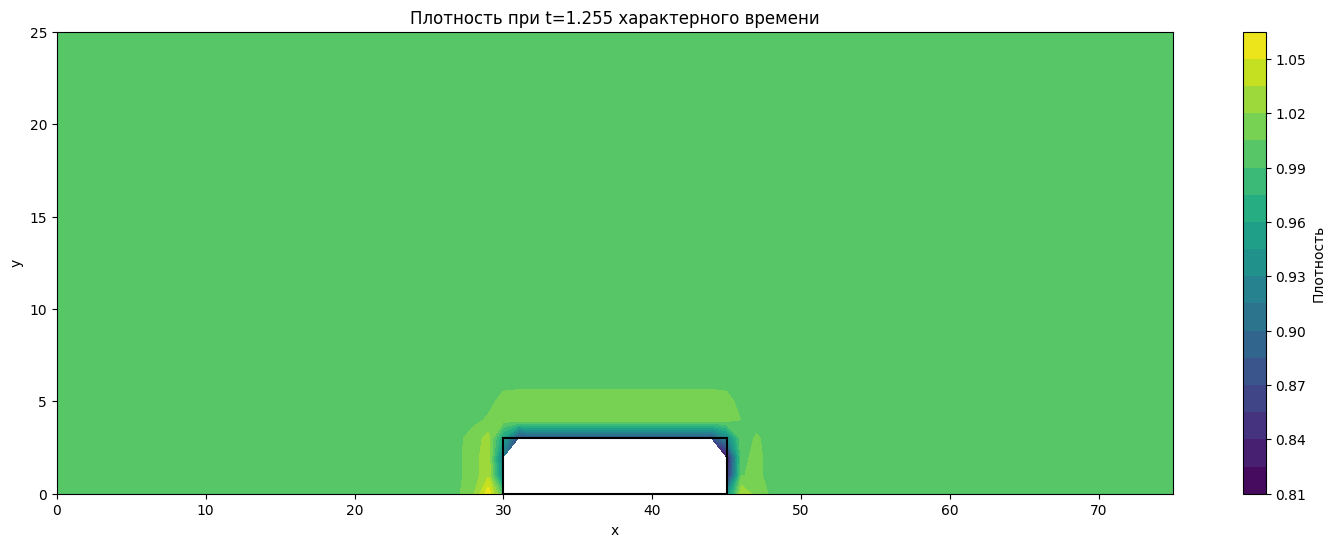

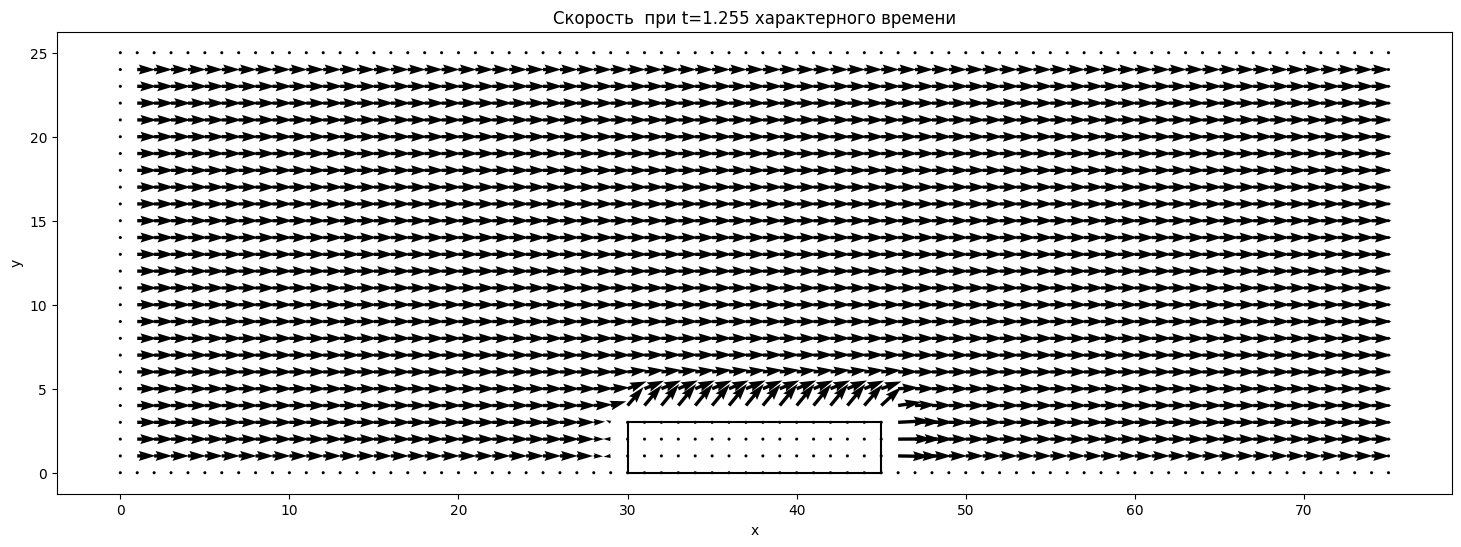

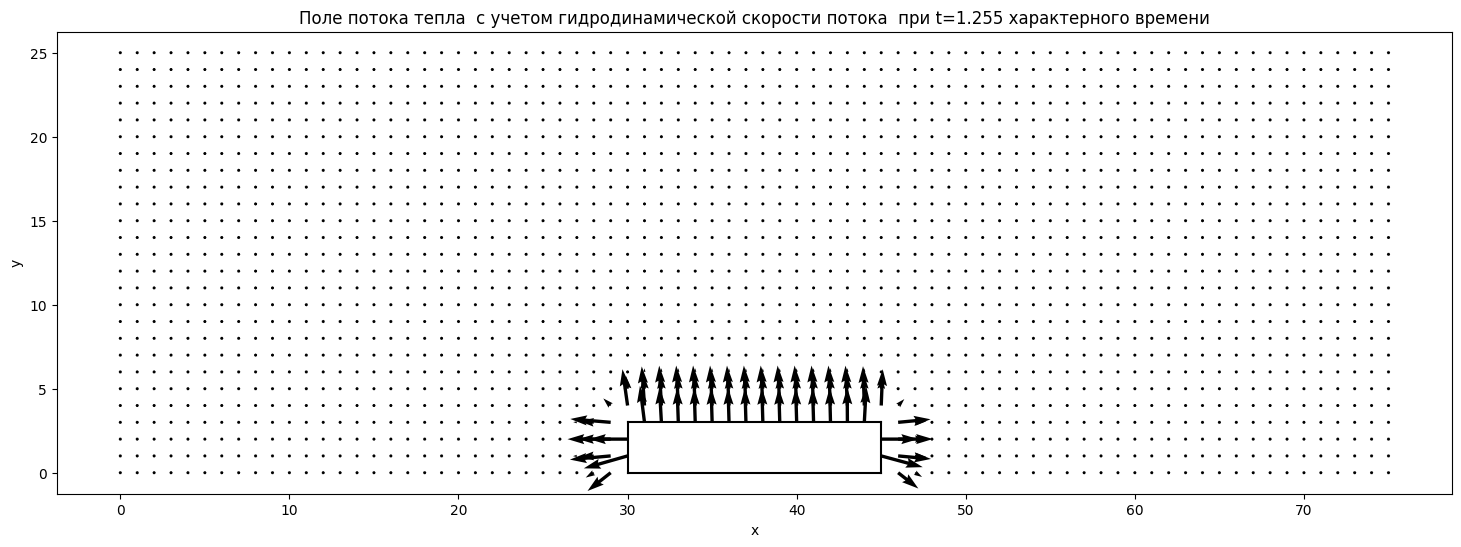

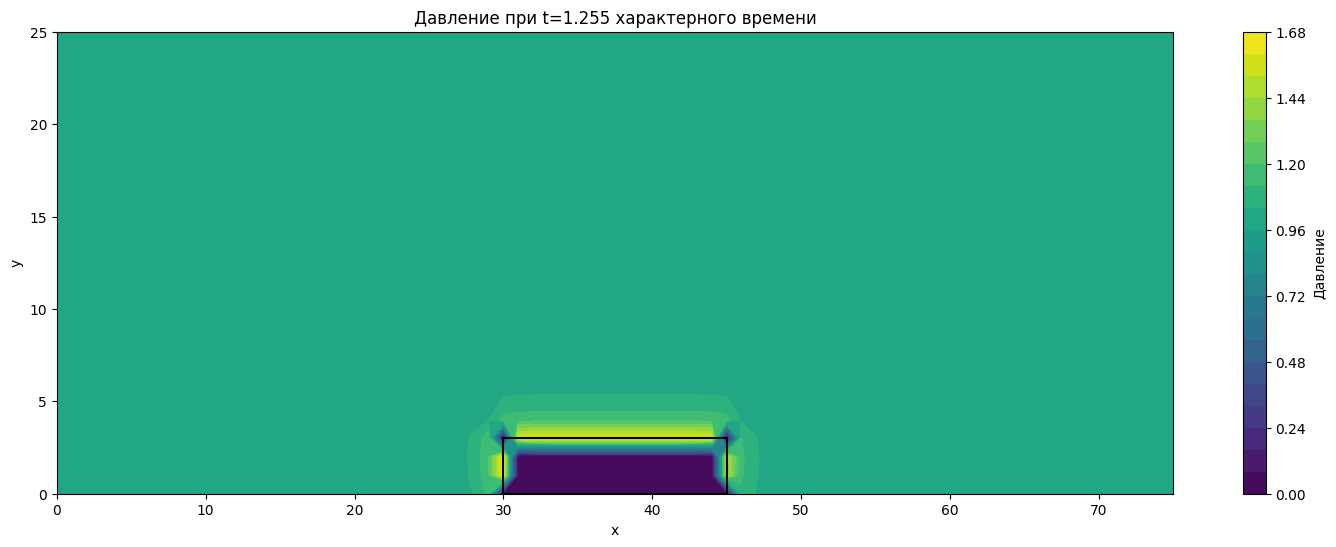

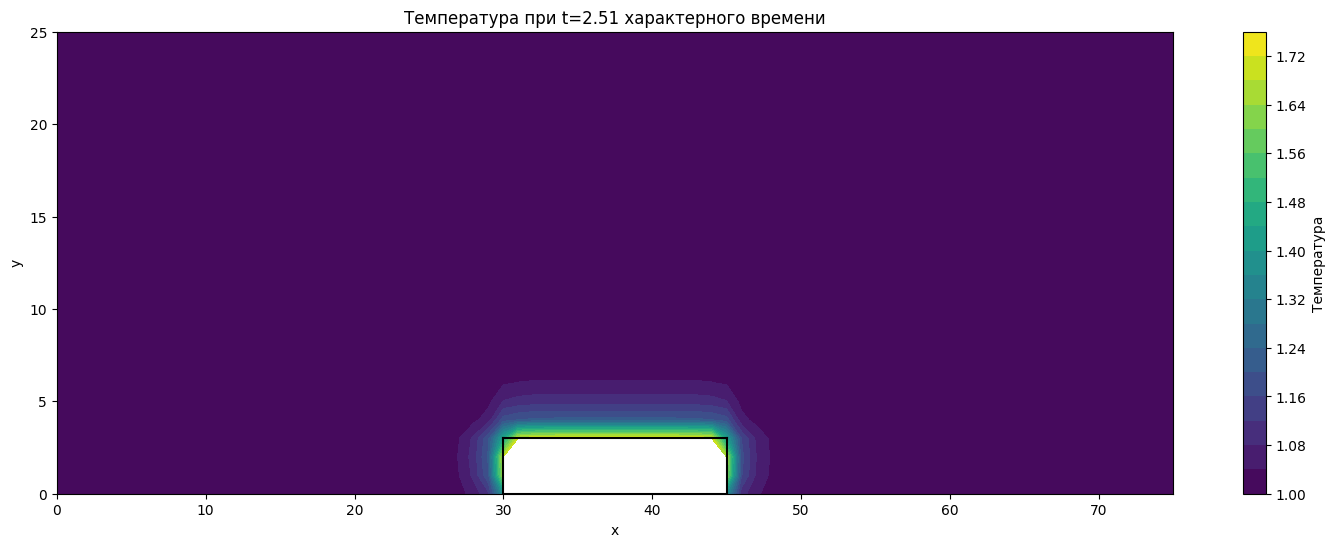

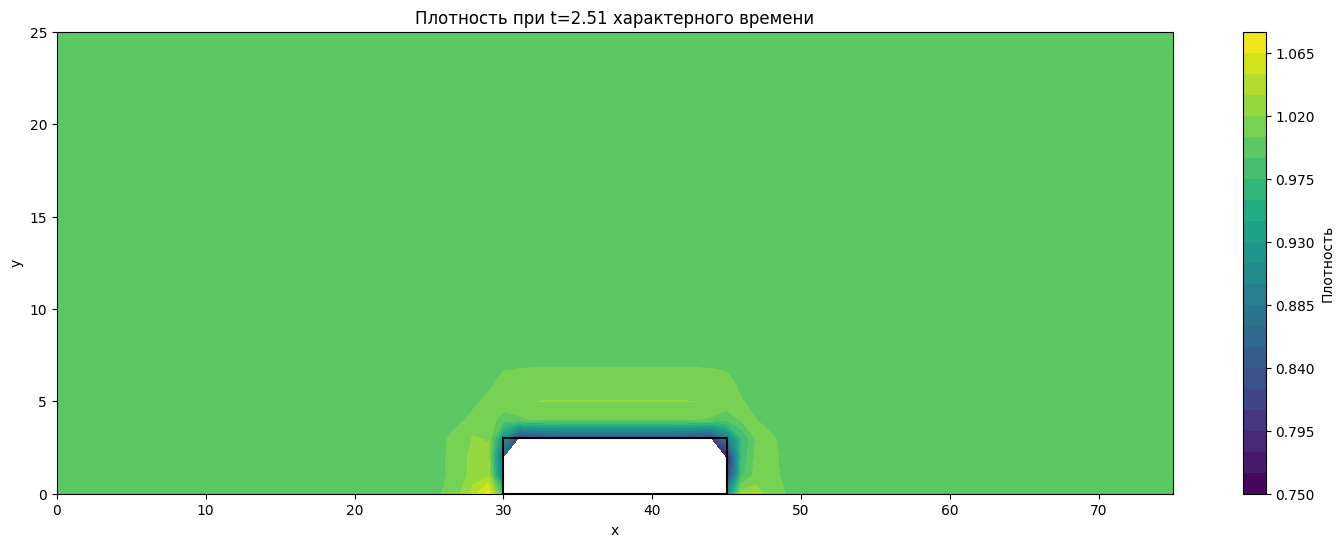

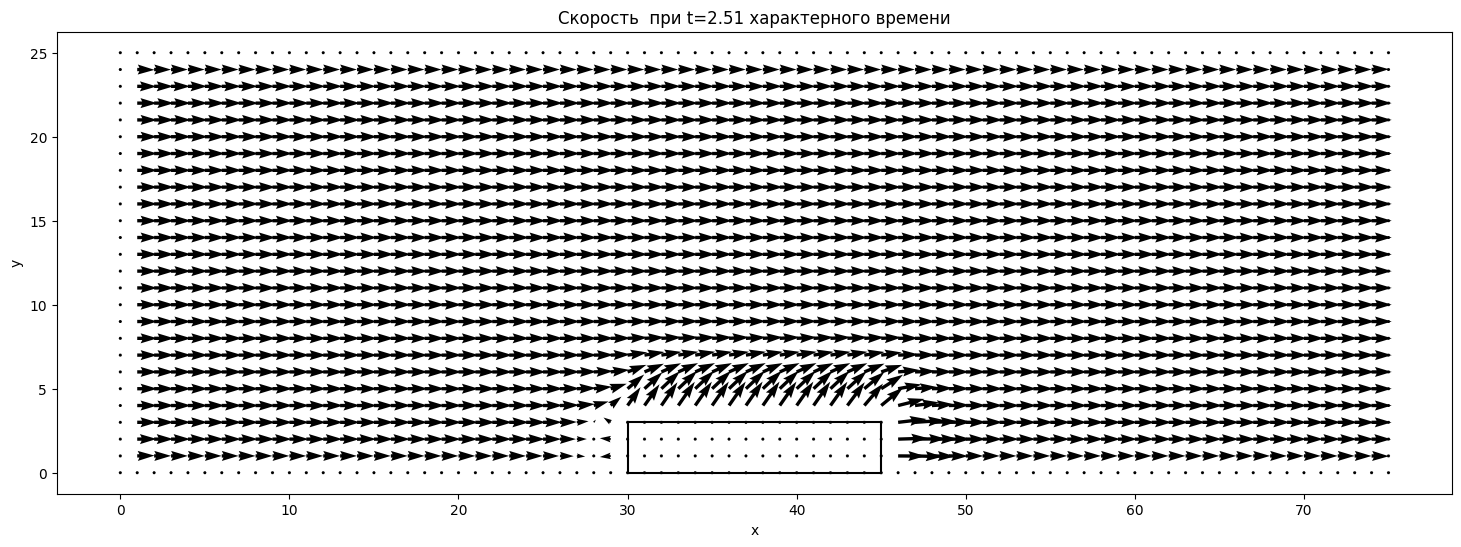

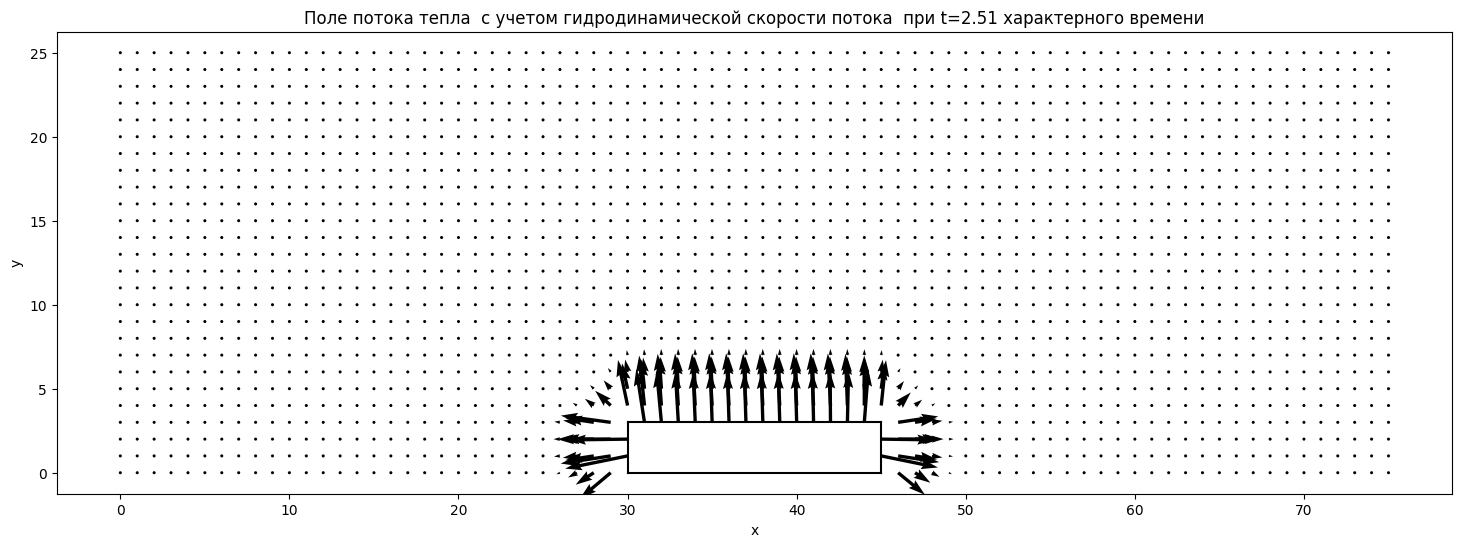

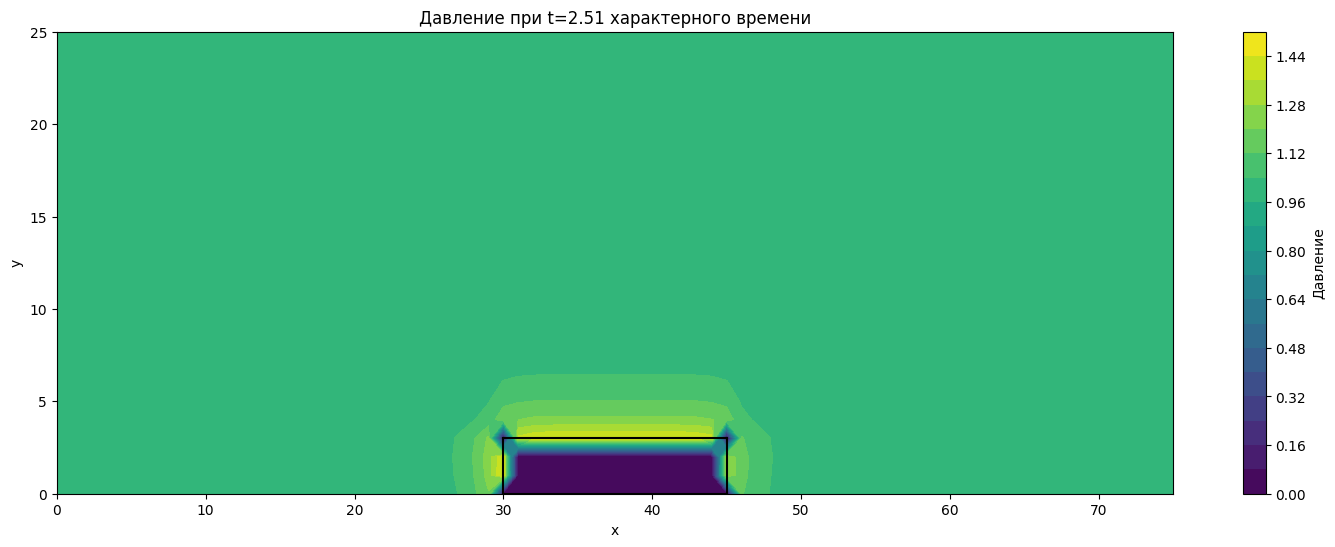

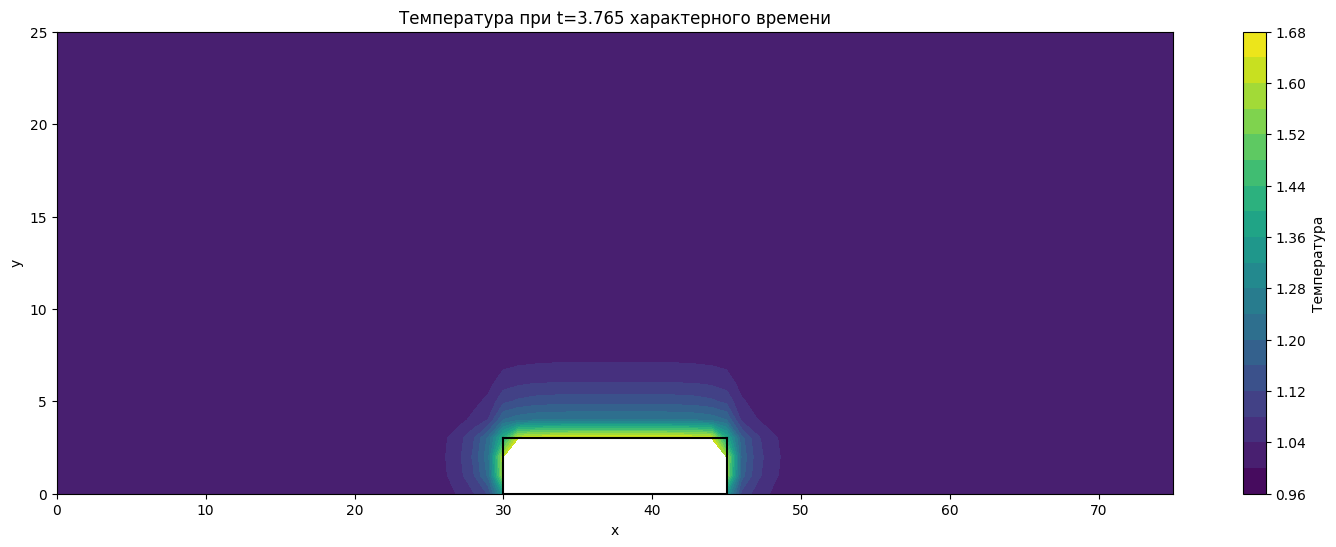

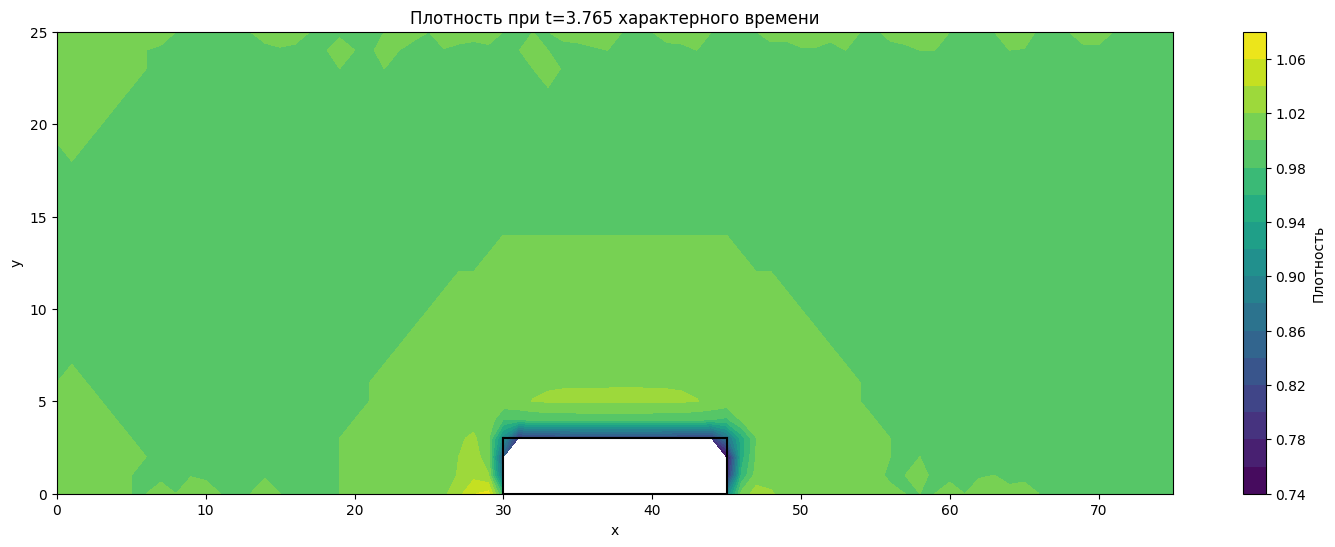

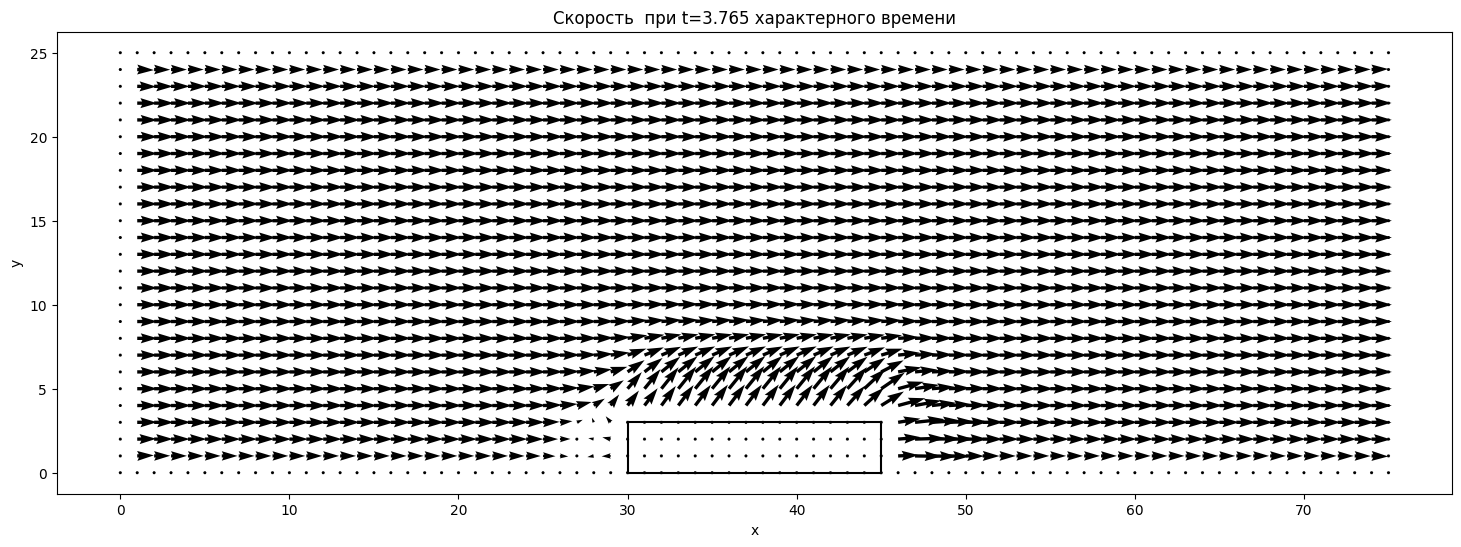

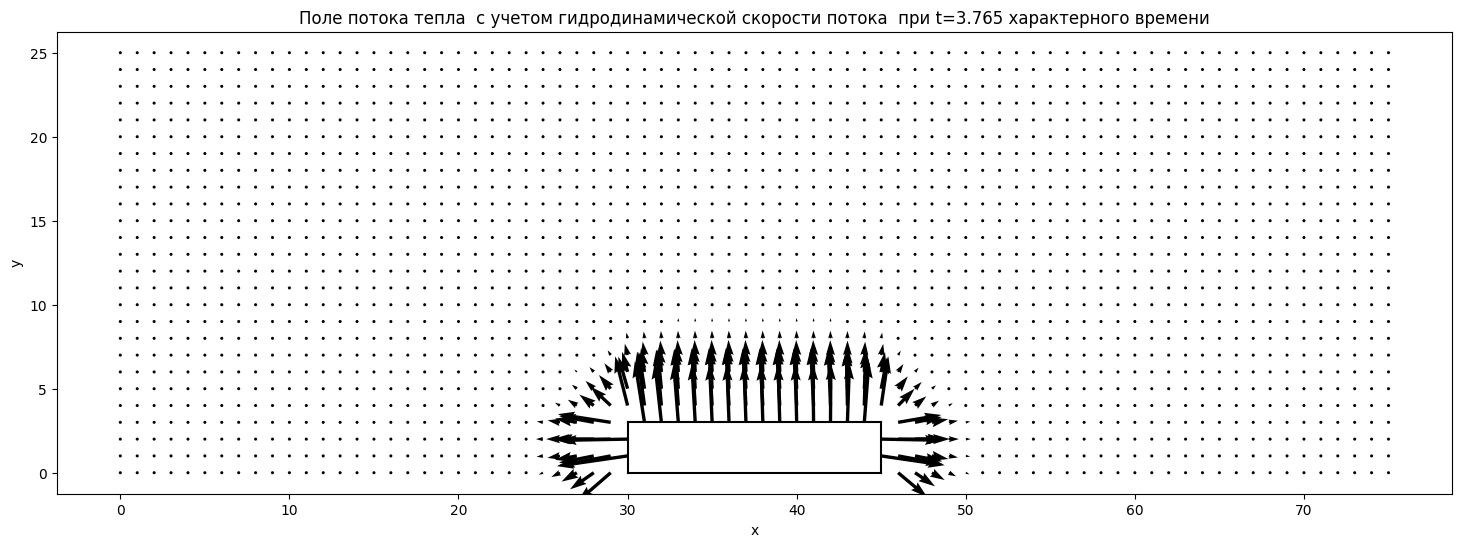

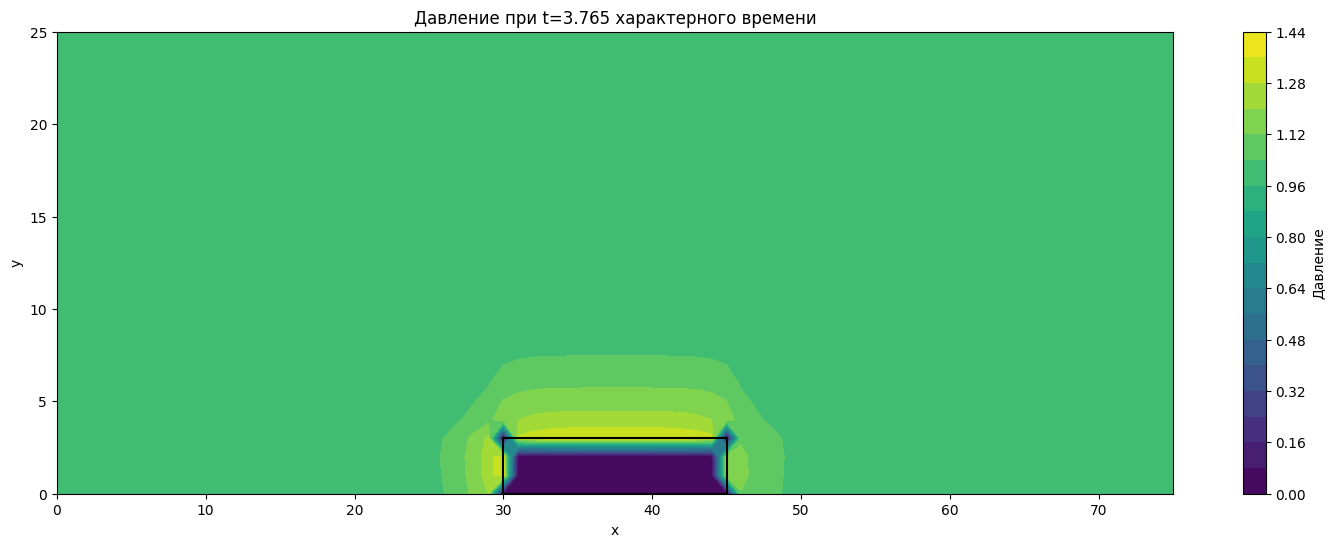

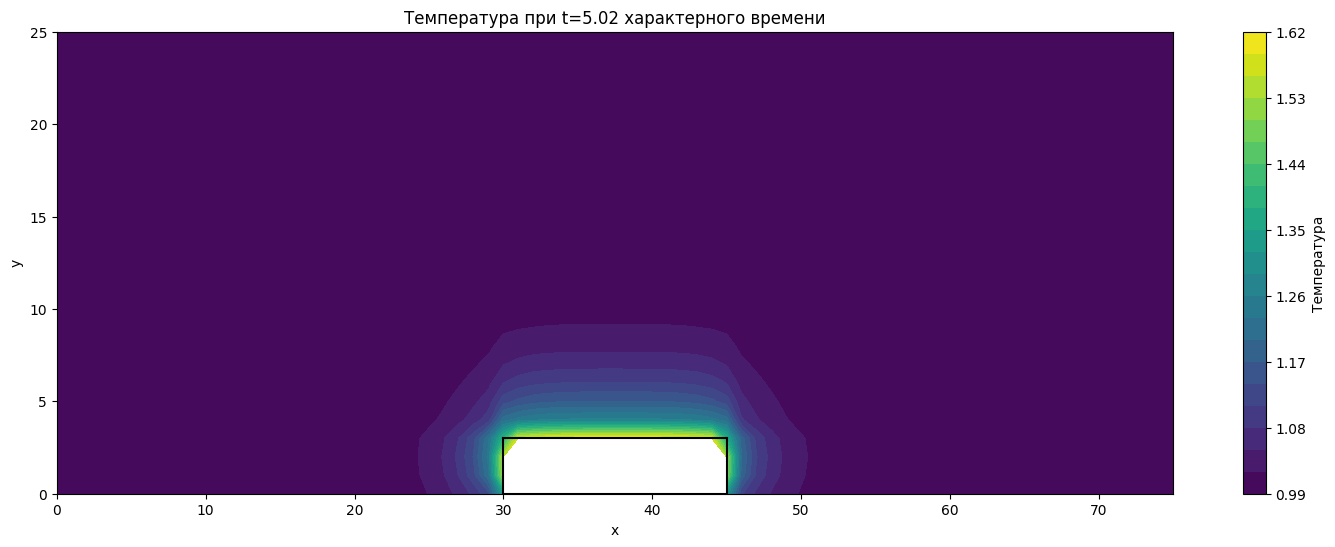

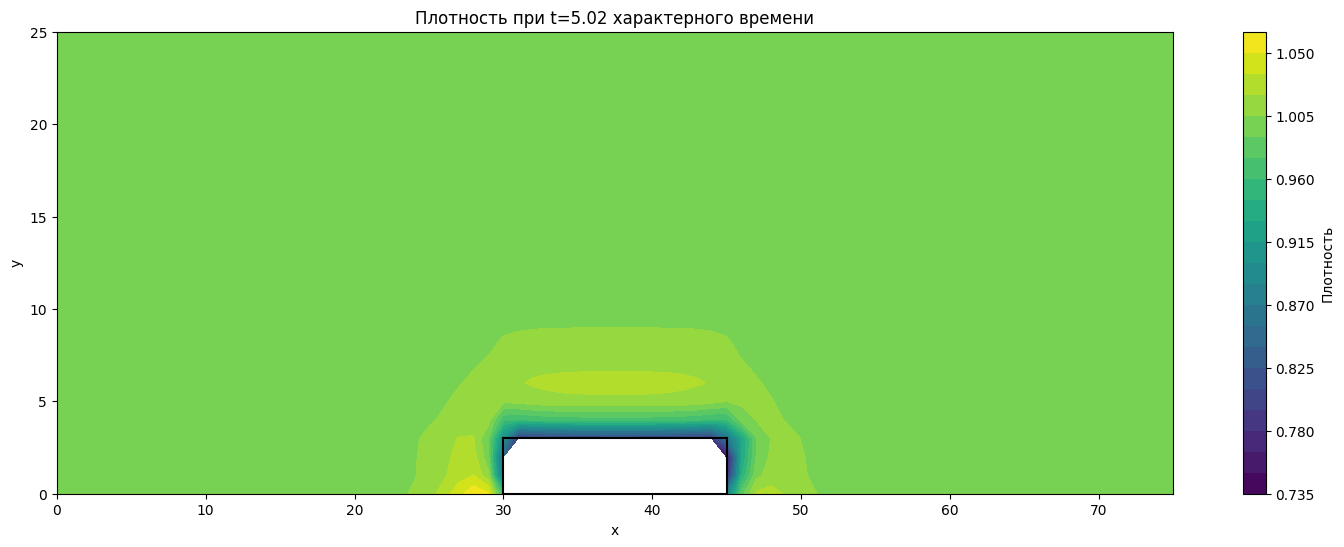

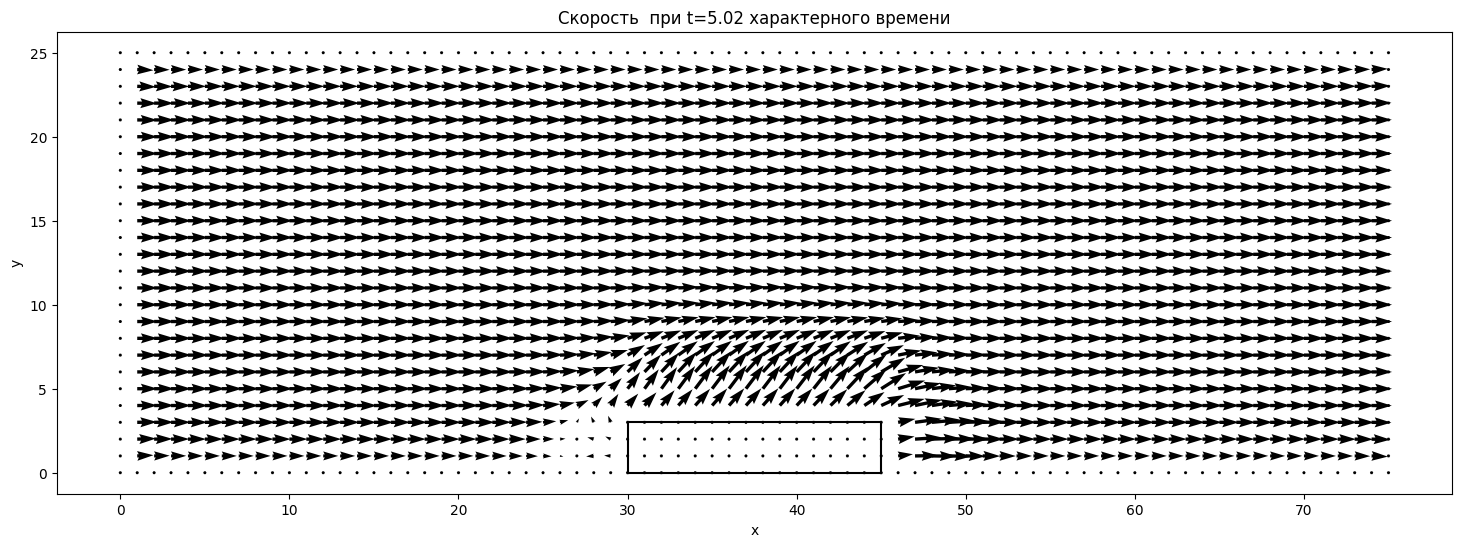

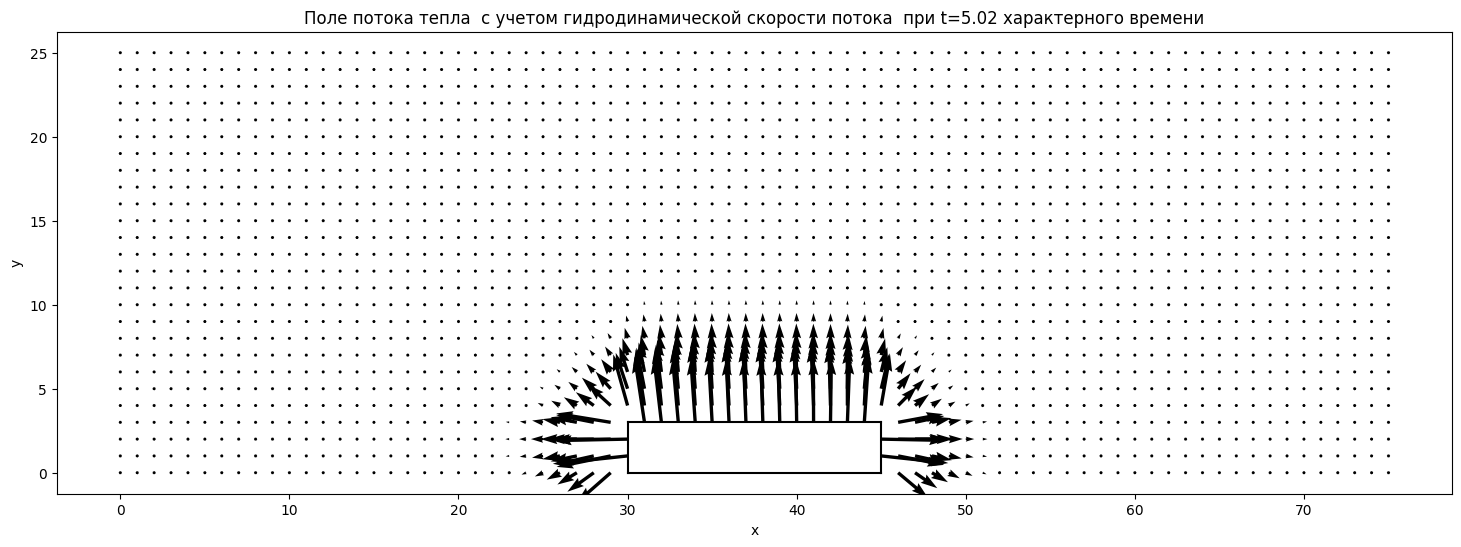

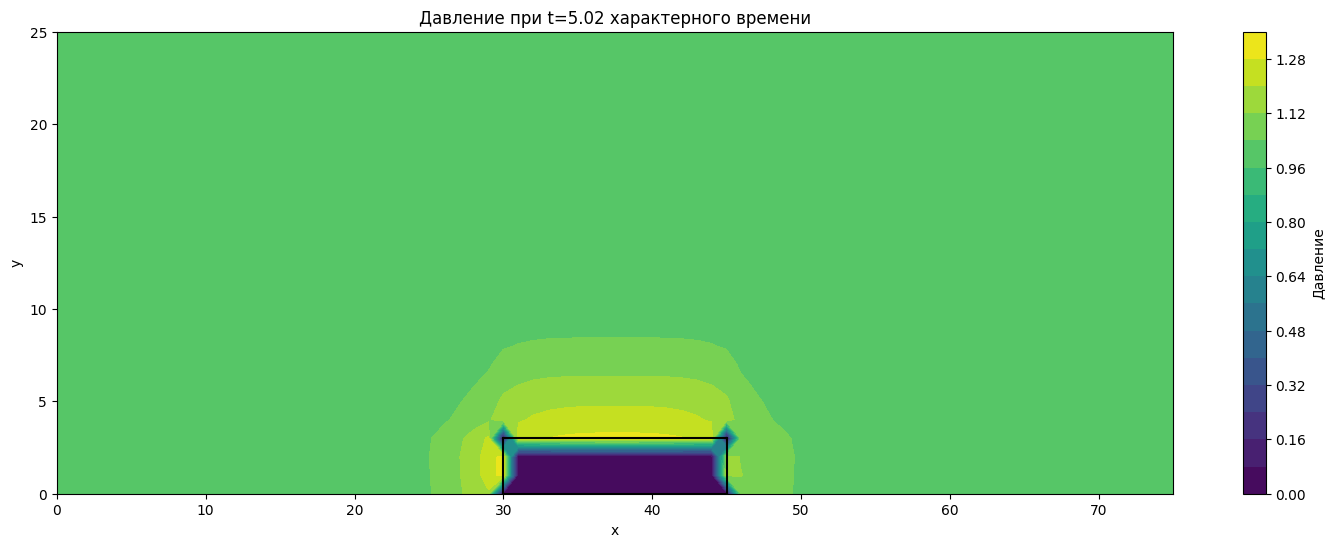

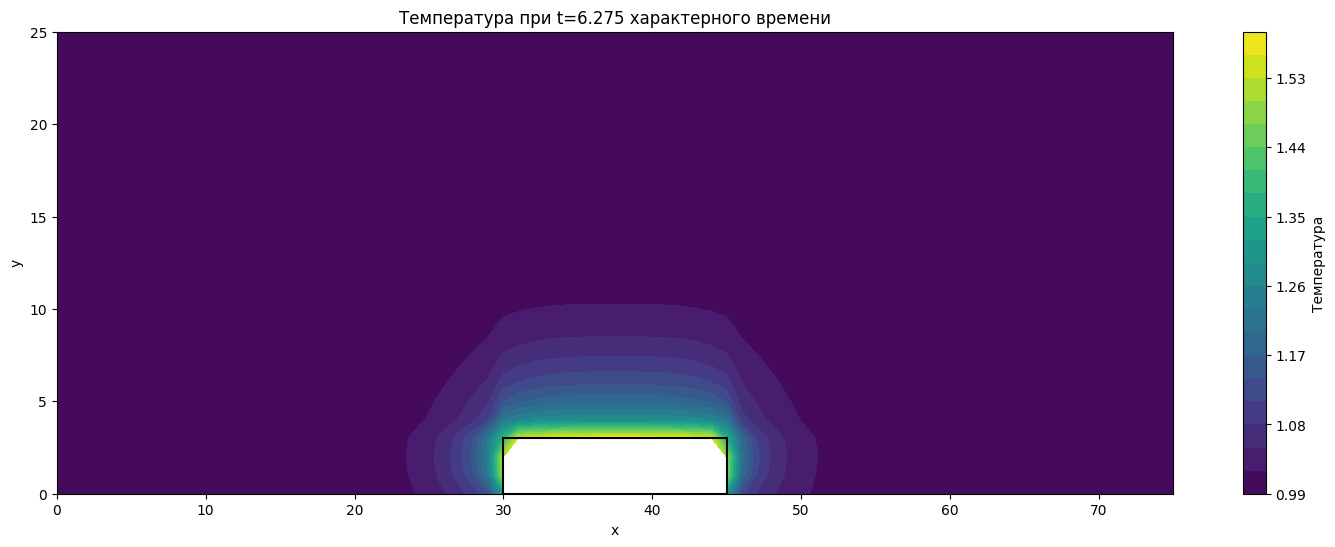

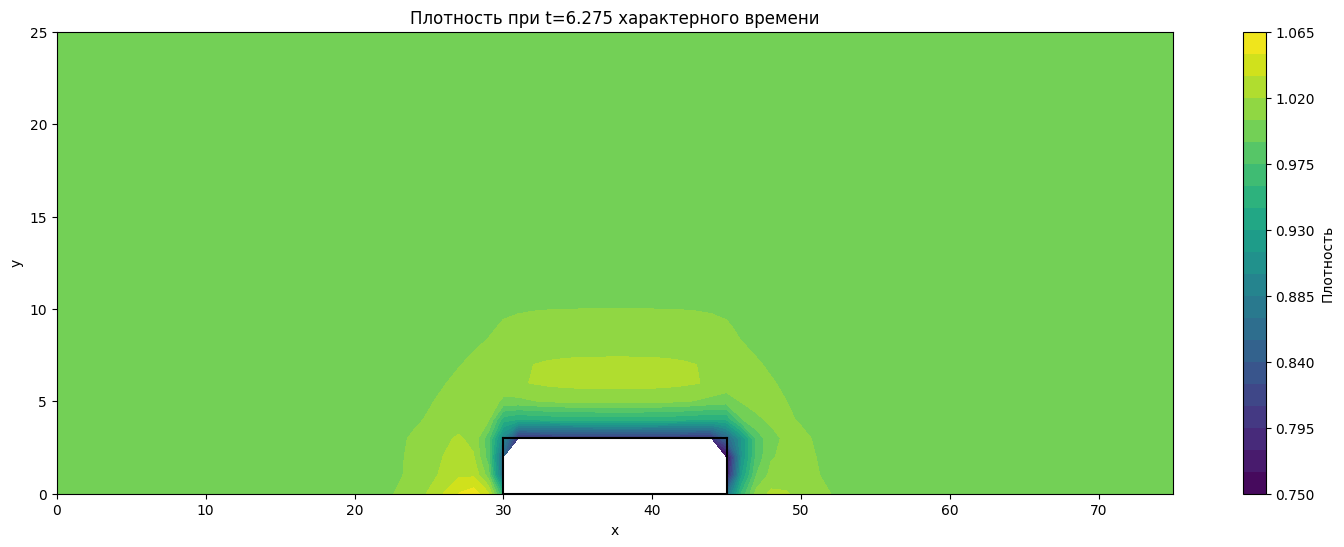

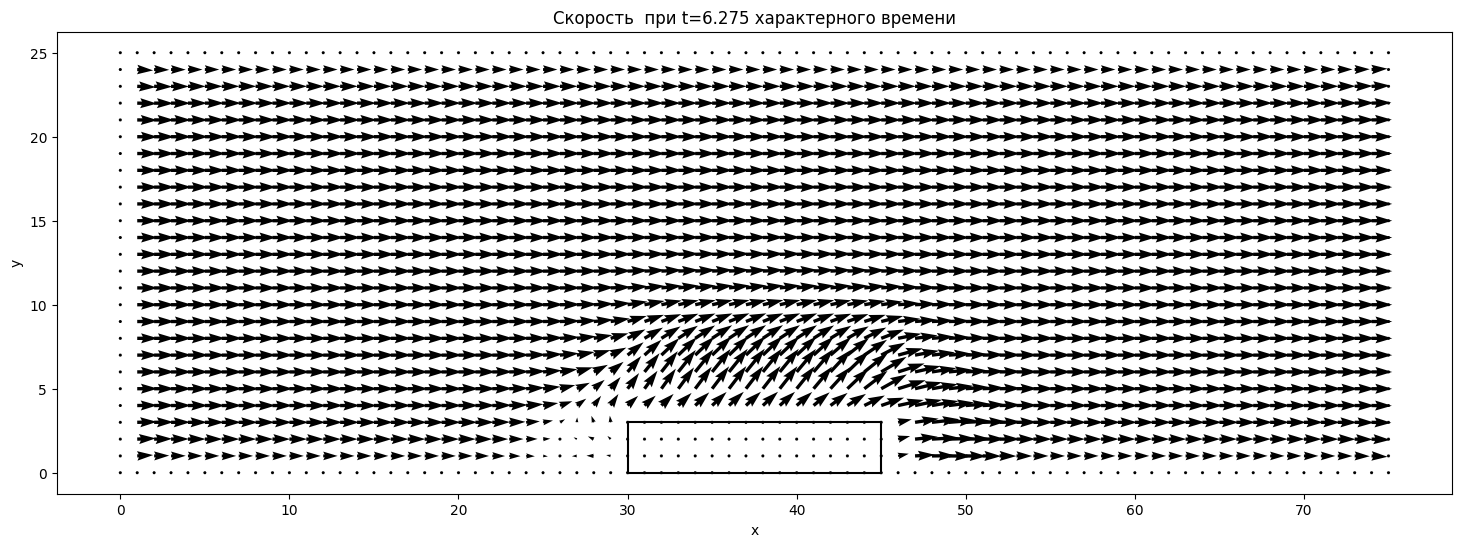

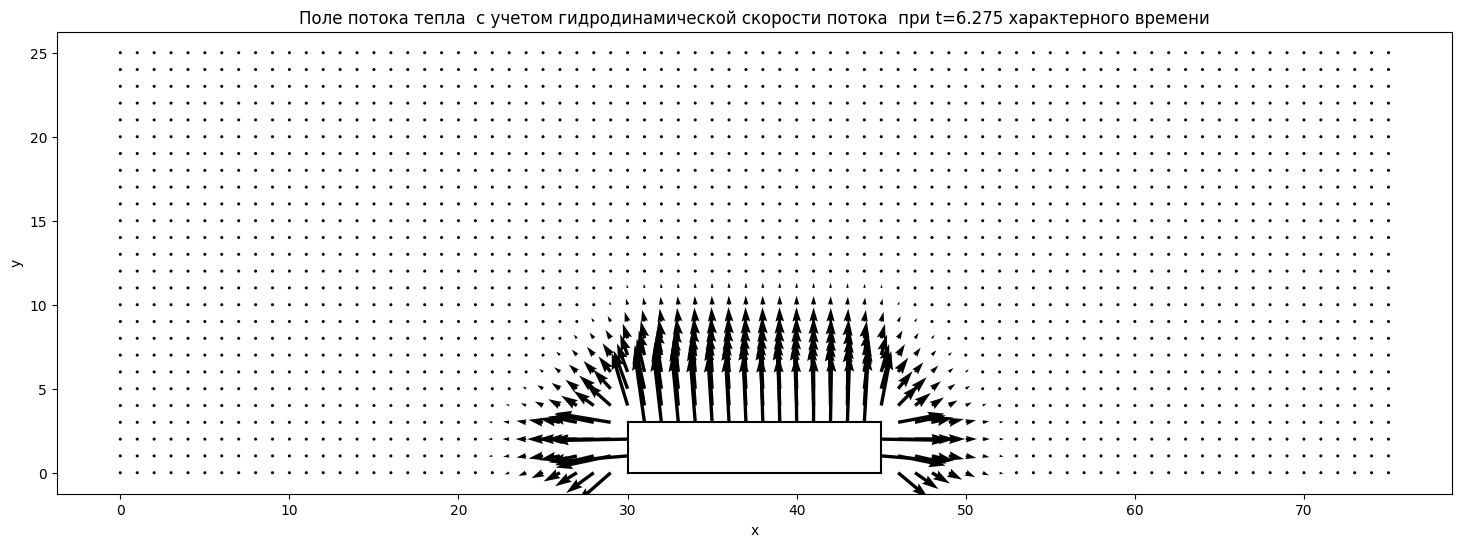

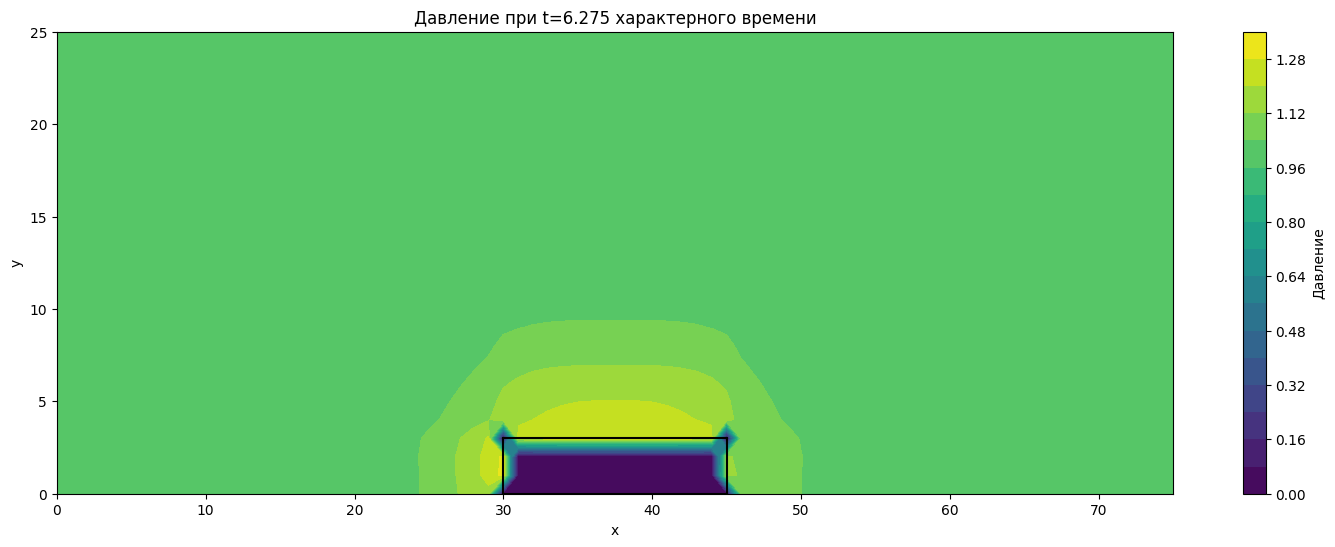

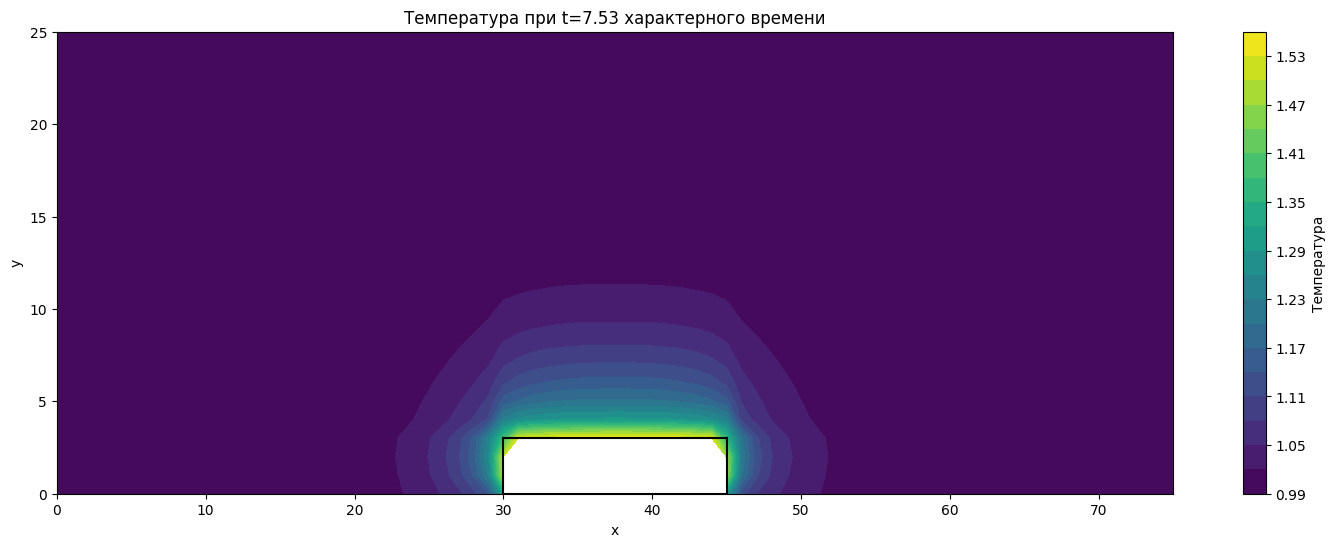

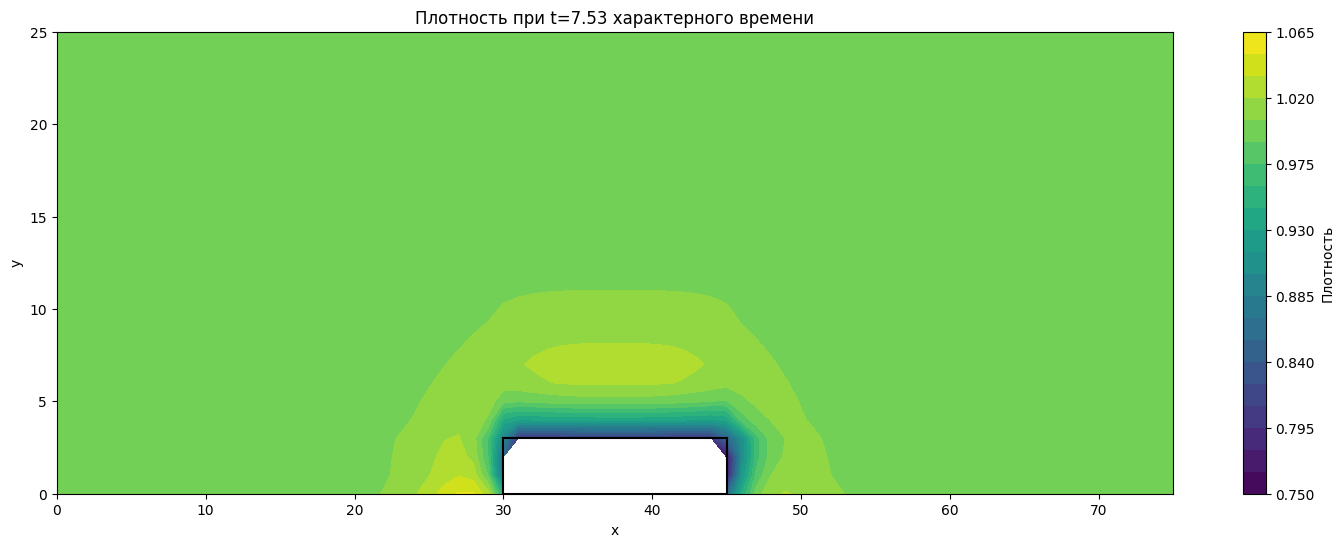

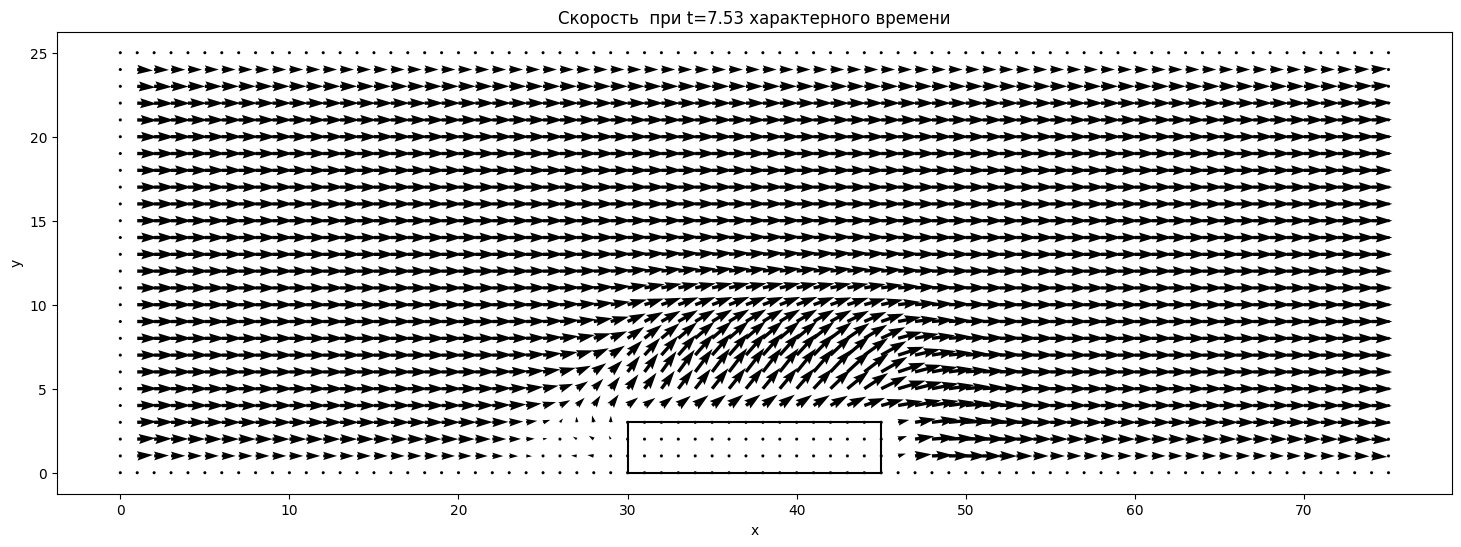

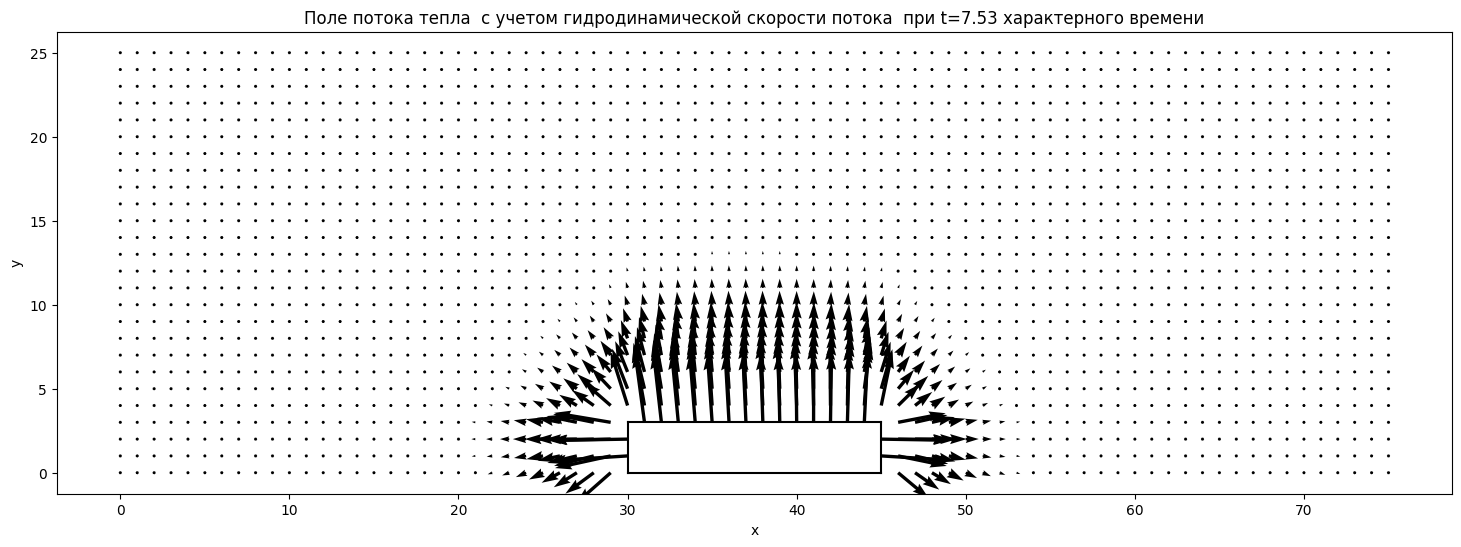

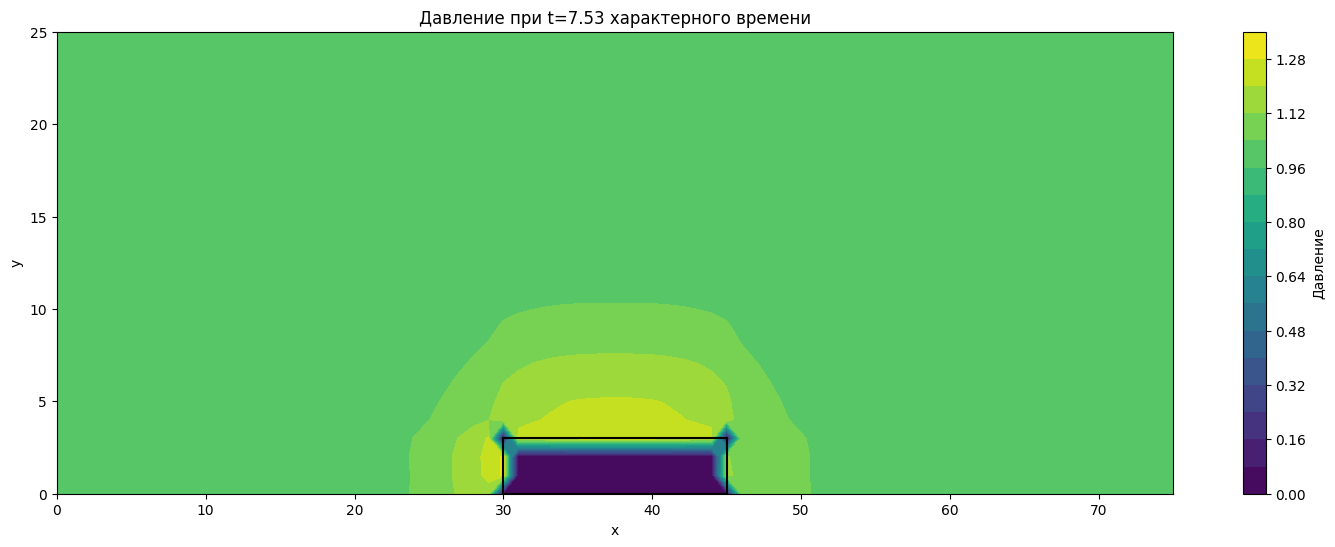

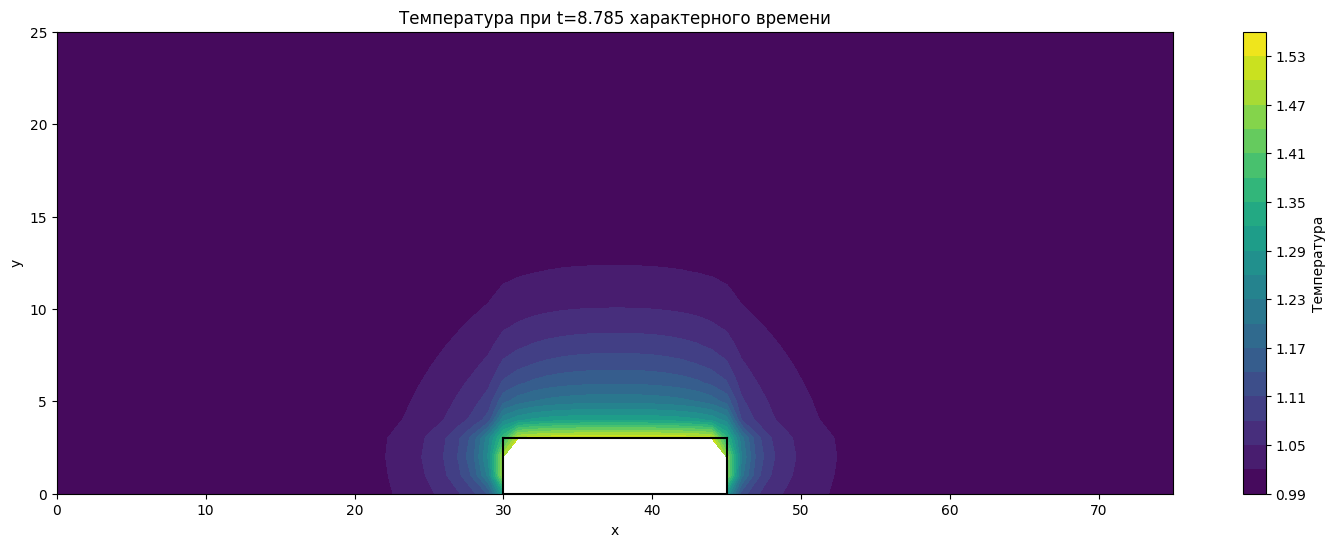

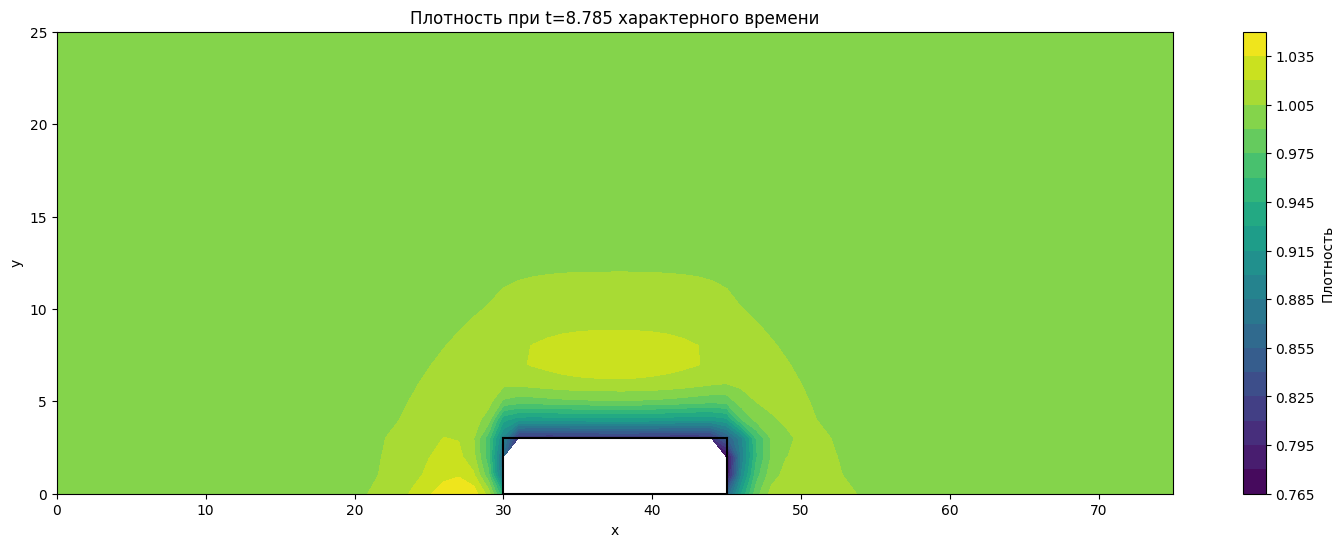

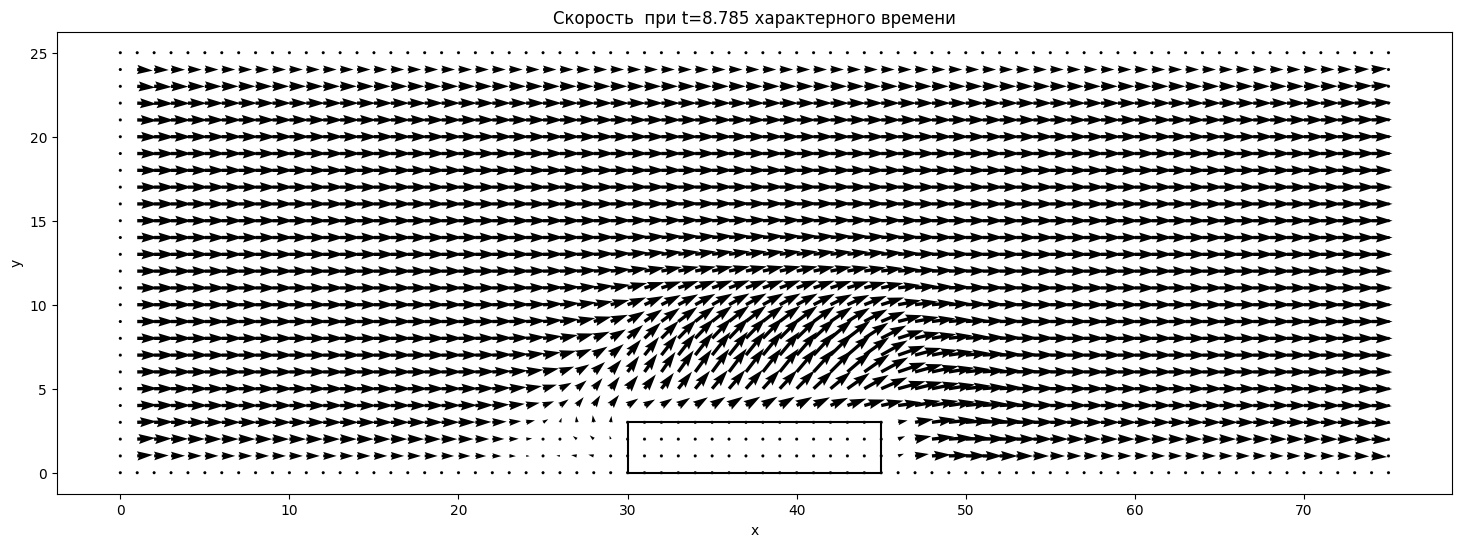

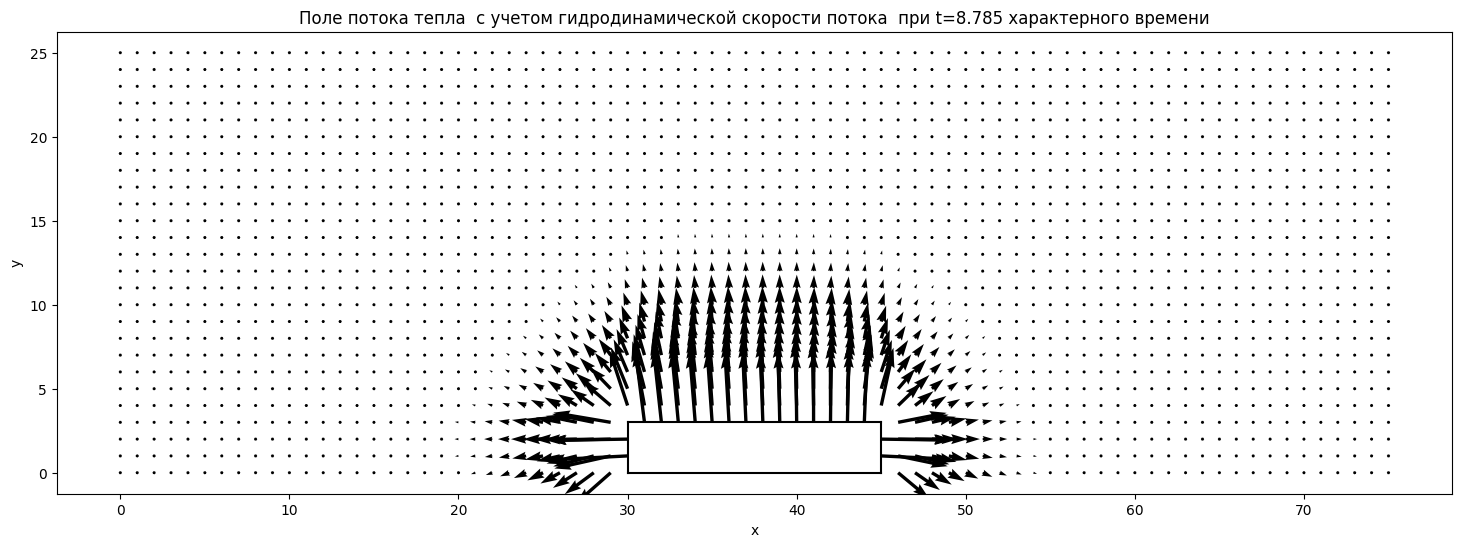

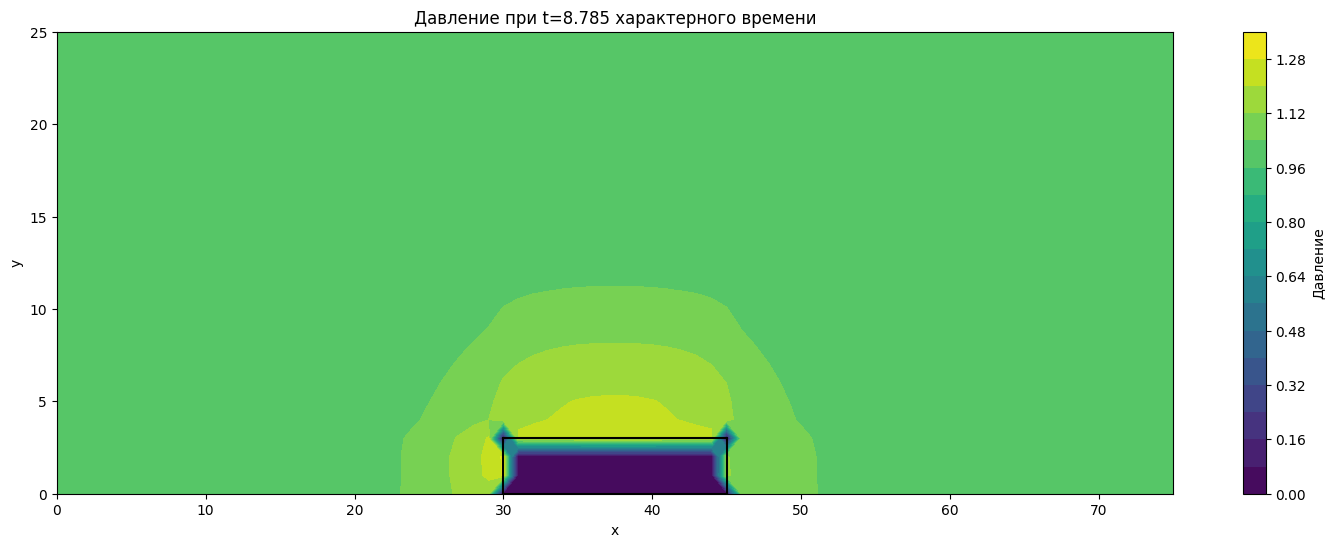

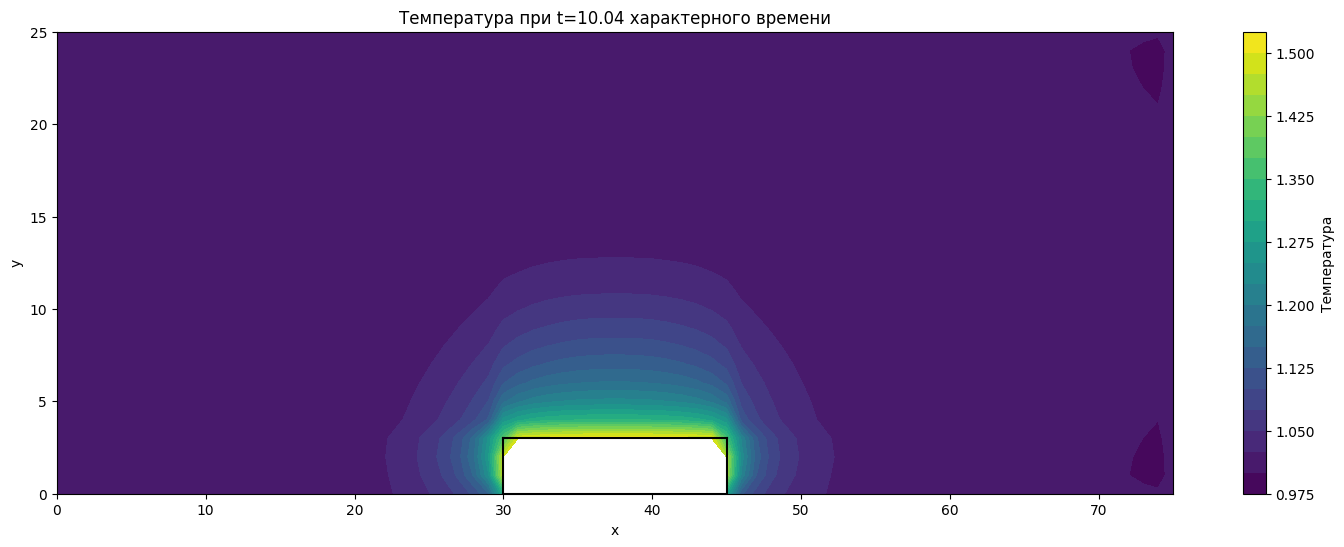

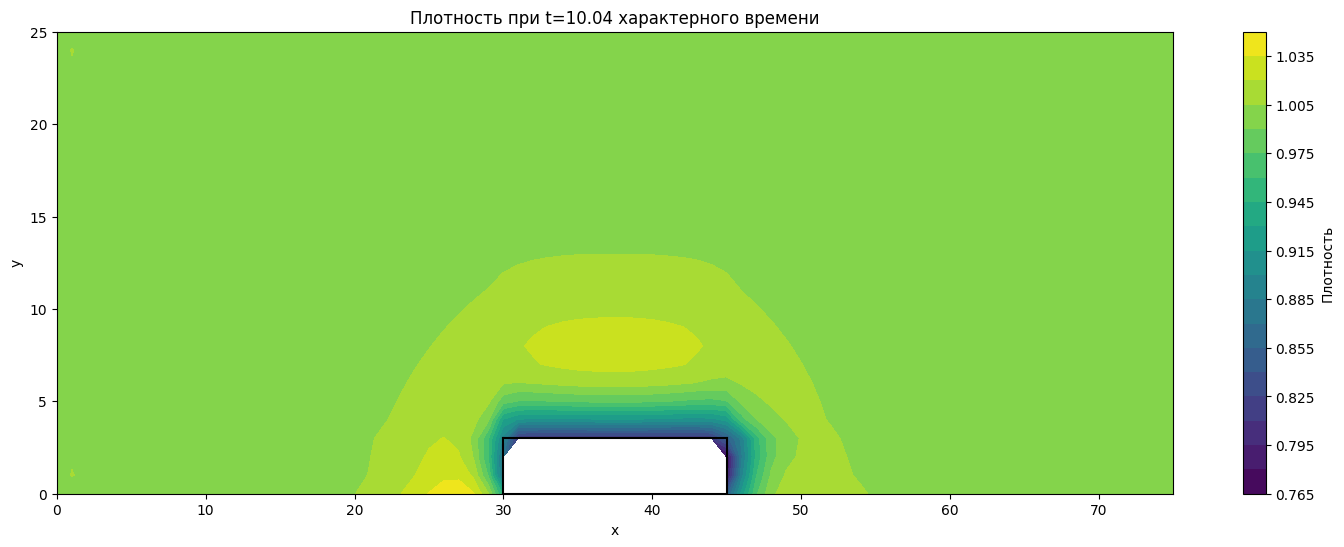

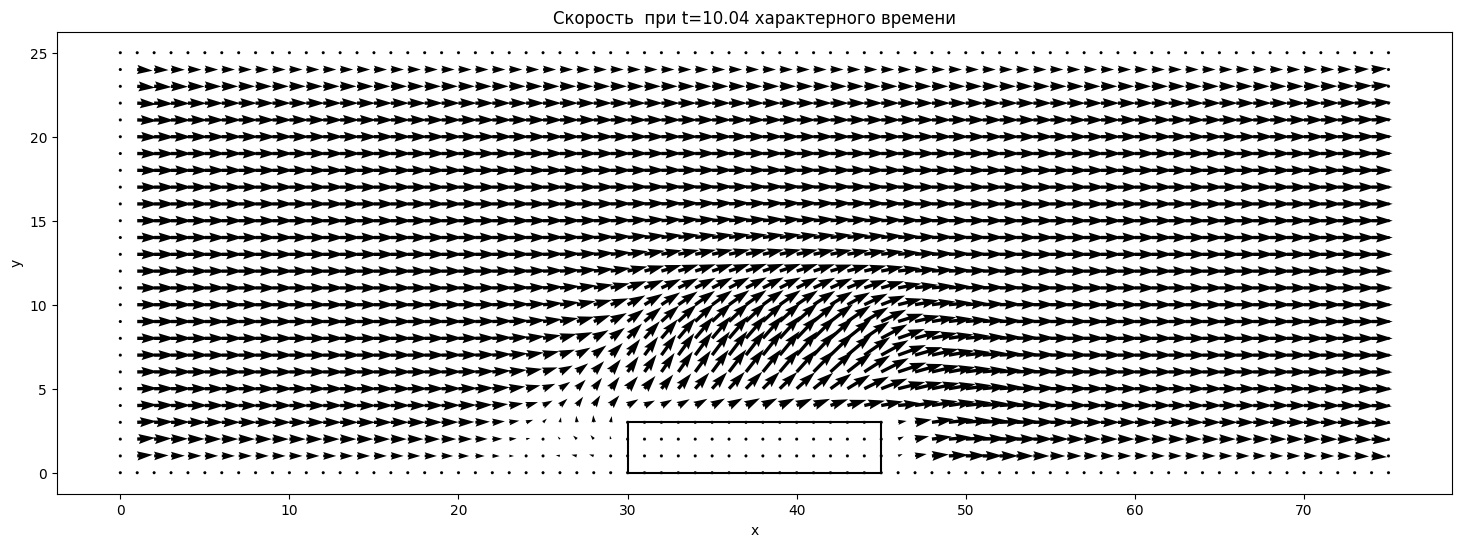

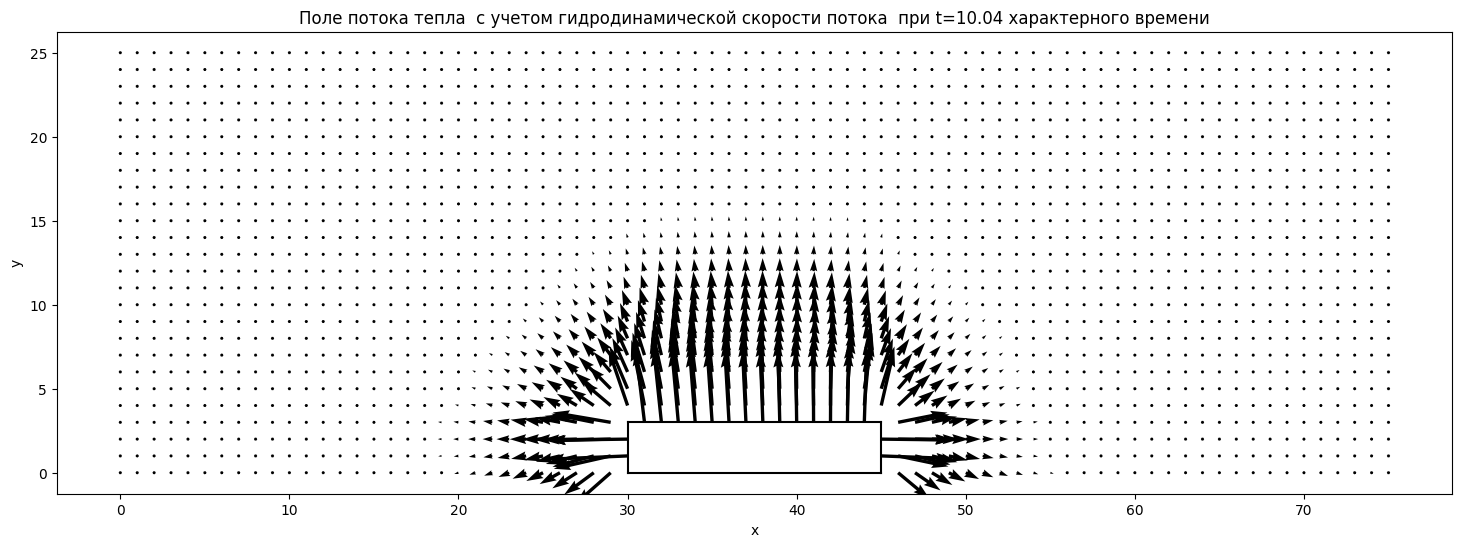

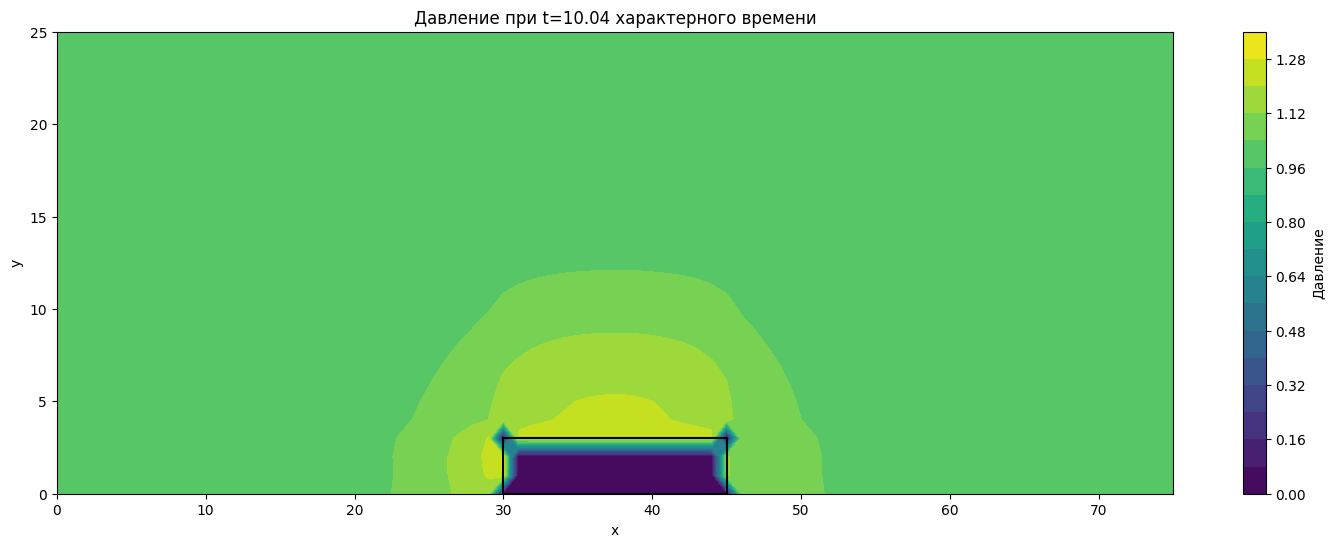

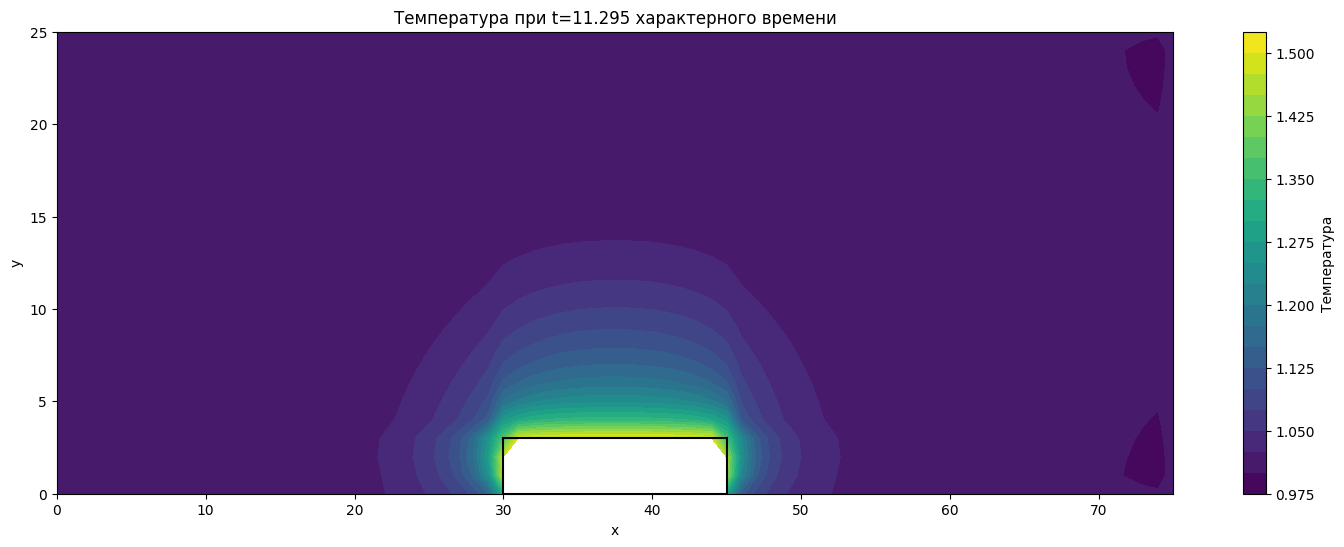

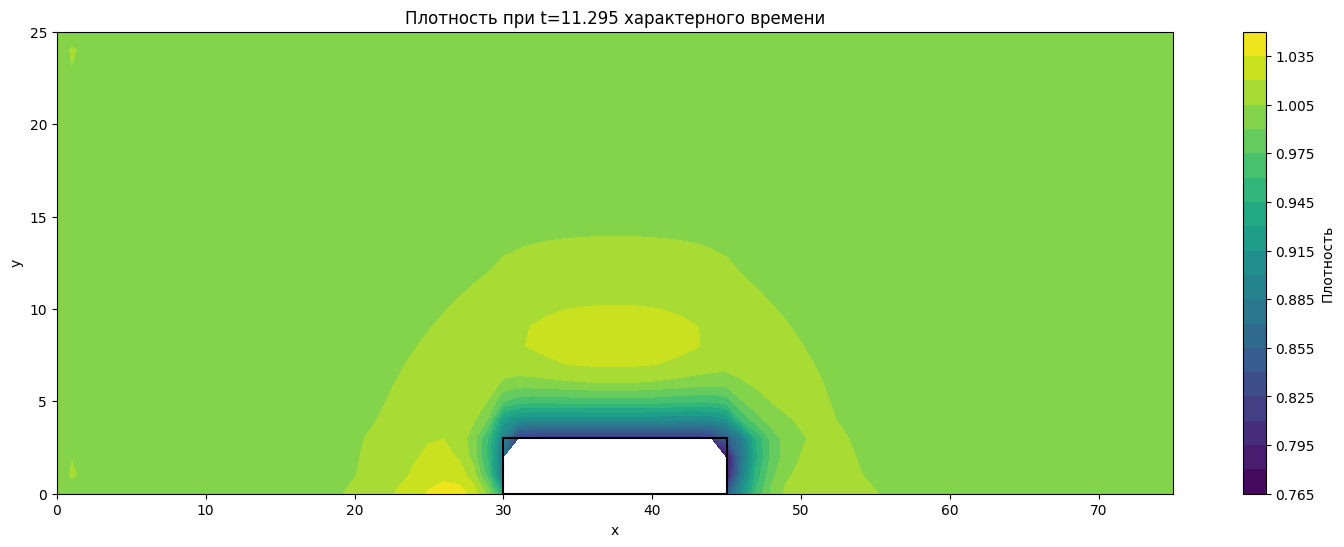

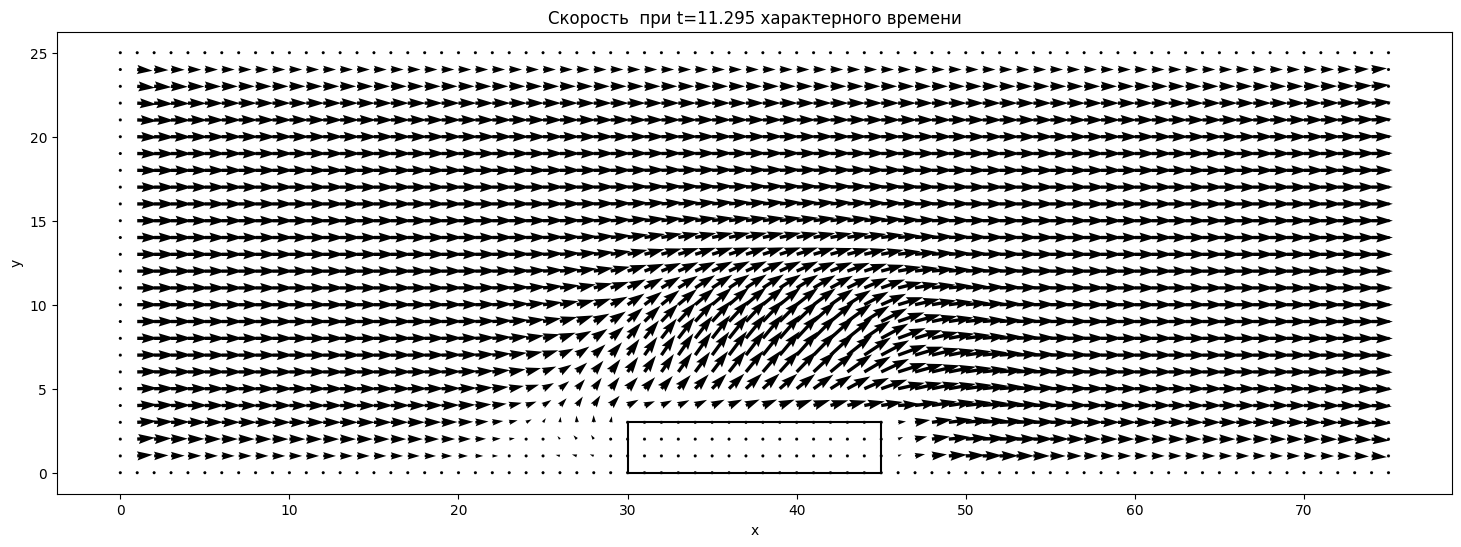

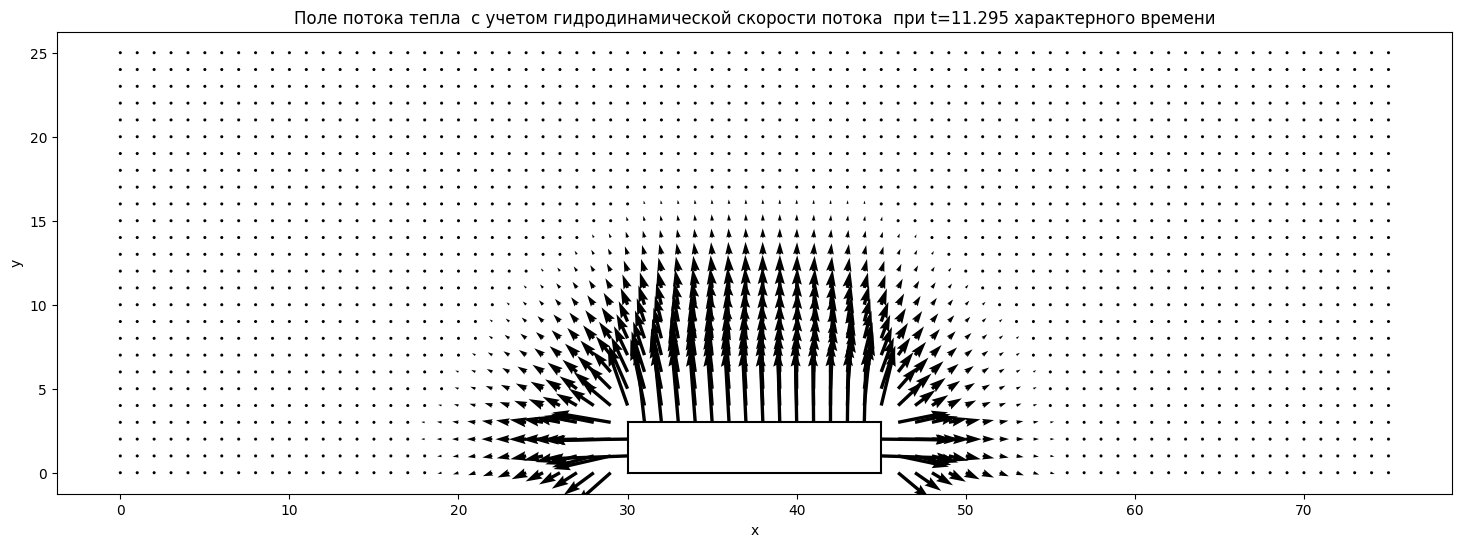

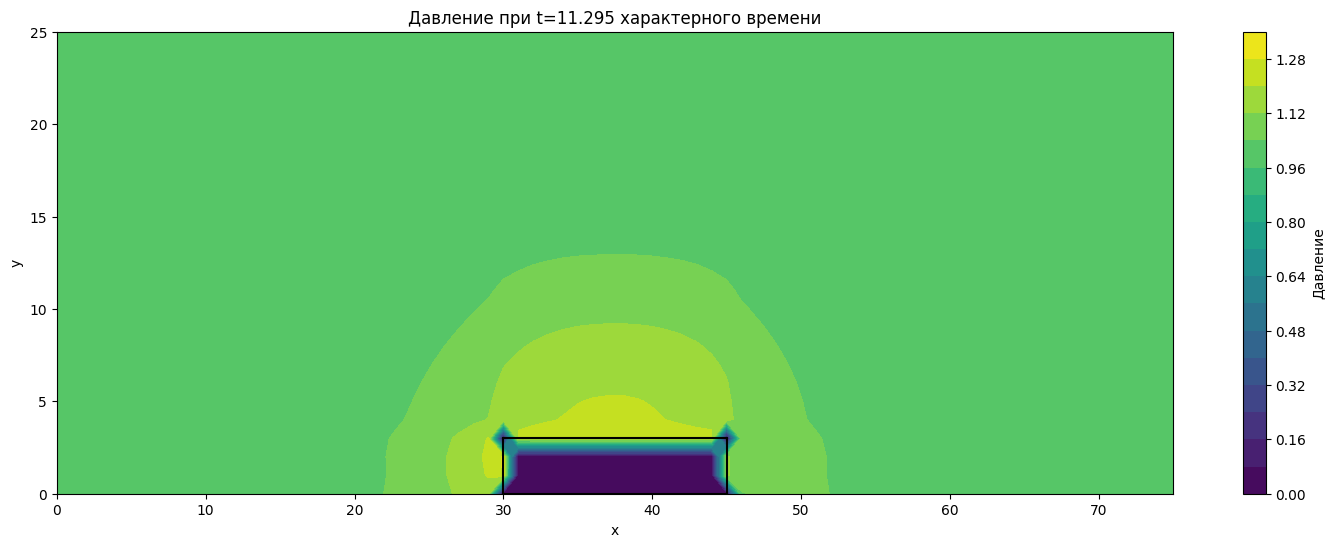

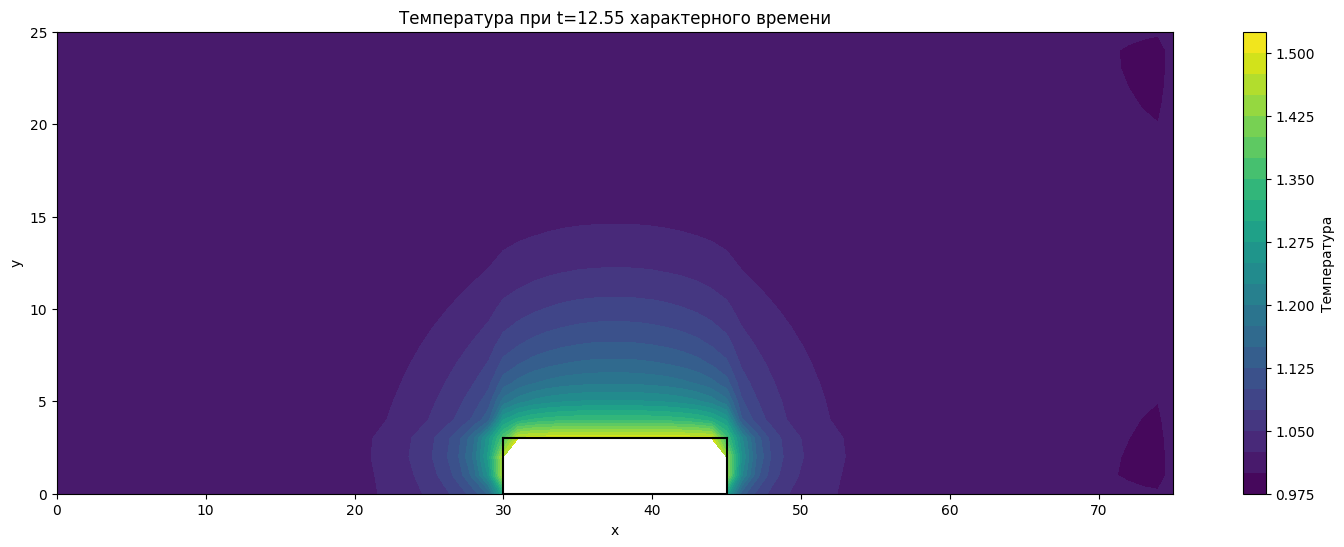

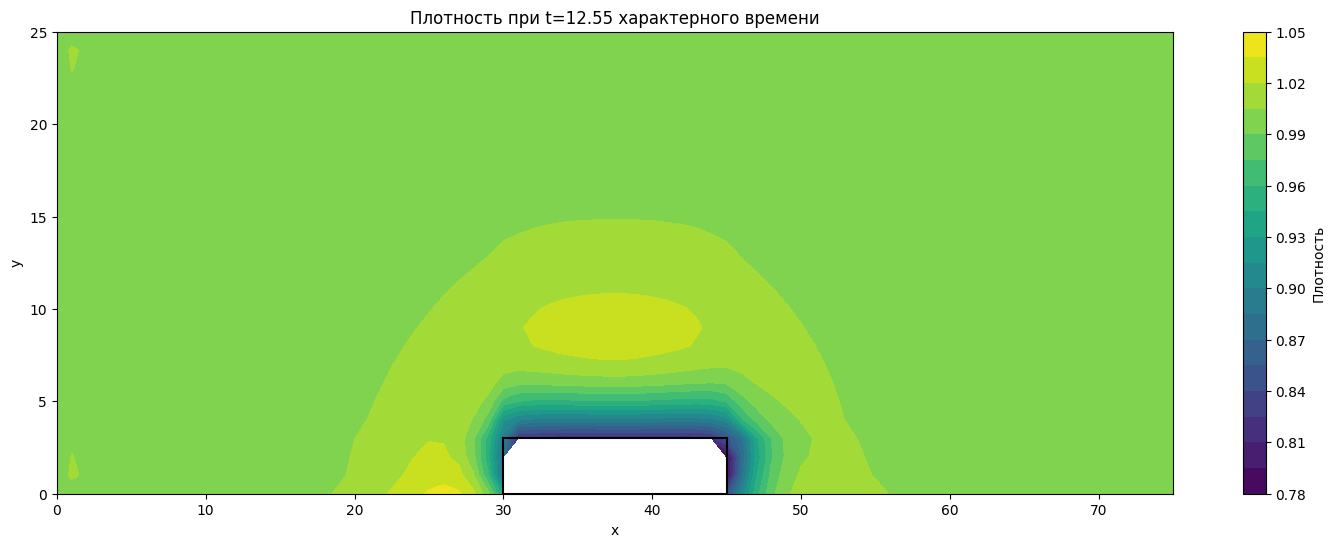

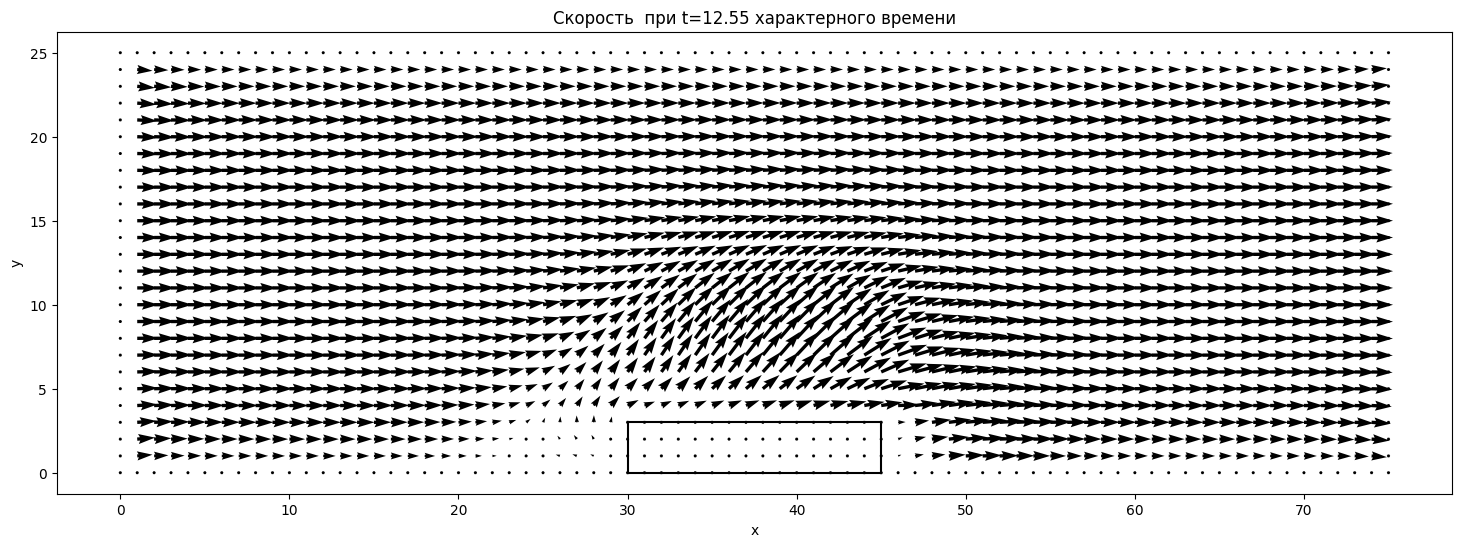

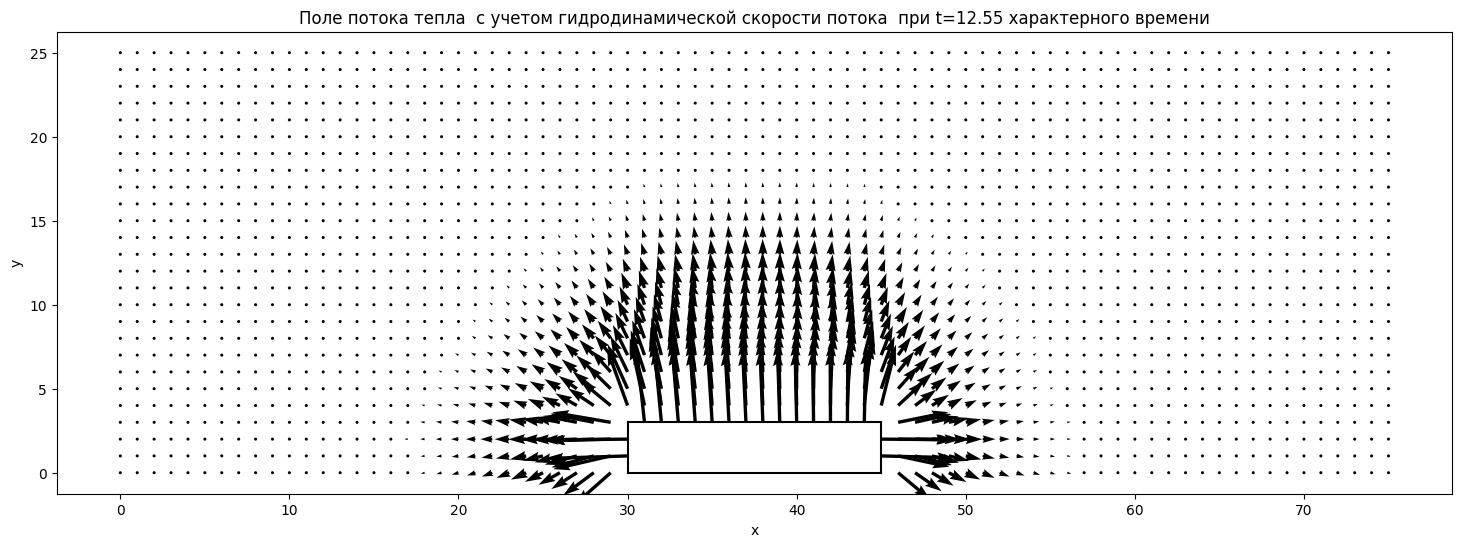

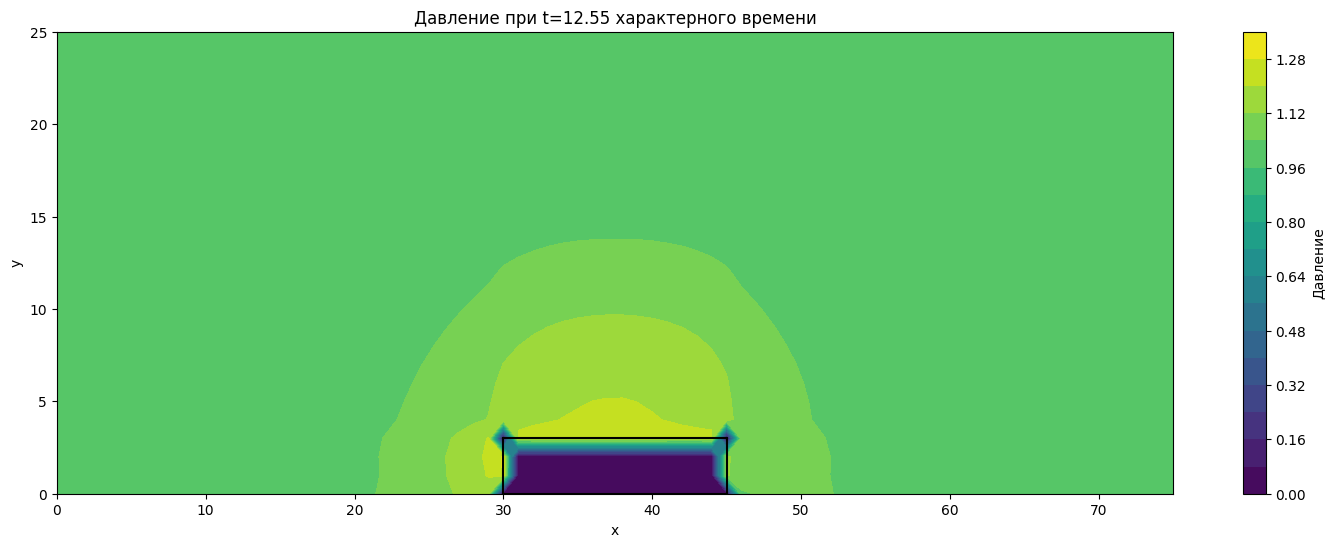

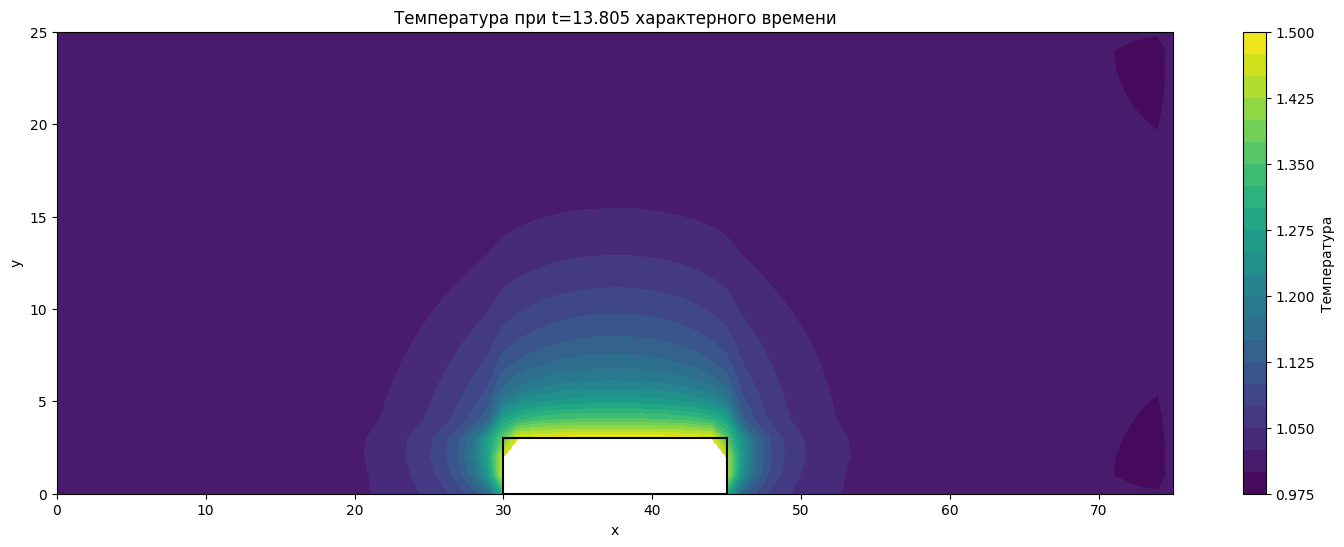

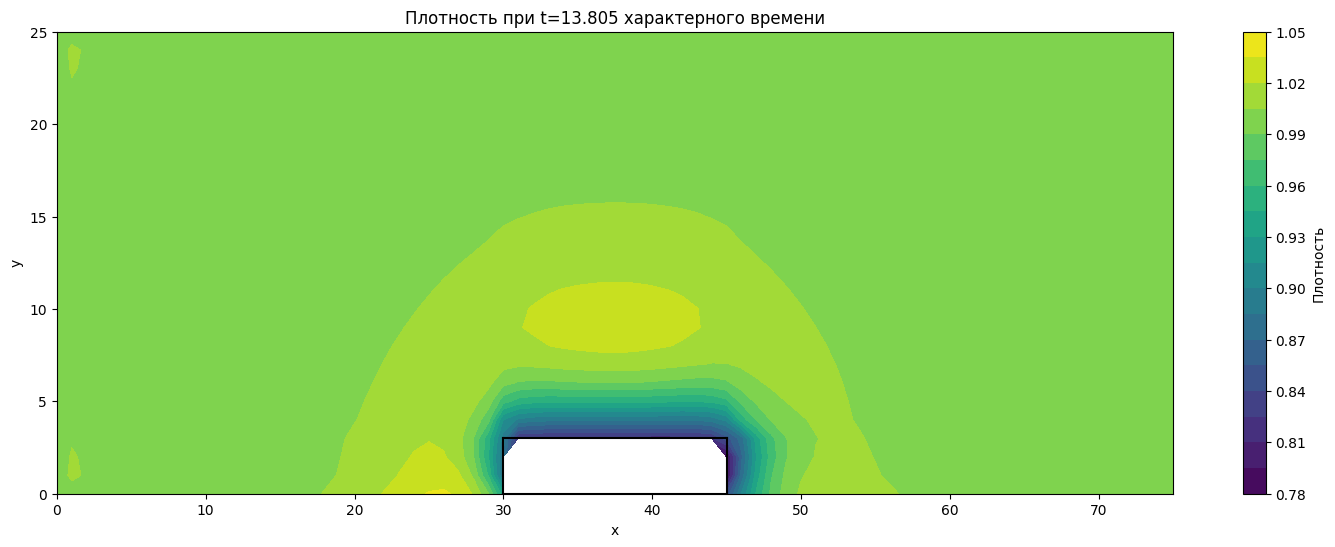

KeyboardInterrupt: 

In [52]:
# Расчет давления как произведение плотности на температуру
data['pressure'] = data['density'] * data['temperature']

def plot_pressure(data, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip):
    pressure_data = data['pressure'].values.reshape((76, 26))
    plt.figure(figsize=(18, 6))
    plt.contourf(X, Y, pressure_data, cmap='viridis', levels=20)
    plt.colorbar(label='Давление')
    plt.title(f'Давление при t={round((kt*dt),3)} характерного времени')
    plt.xlabel('x')
    plt.ylabel('y')
    # Очерчивание периметра чипа
    plt.plot([x_min_chip, x_max_chip], [y_min_chip, y_min_chip], 'k-')
    plt.plot([x_min_chip, x_max_chip], [y_max_chip, y_max_chip], 'k-')
    plt.plot([x_min_chip, x_min_chip], [y_min_chip, y_max_chip], 'k-')
    plt.plot([x_max_chip, x_max_chip], [y_min_chip, y_max_chip], 'k-')
   # plt.savefig(f'pressure_{kt}.png')  # Сохранение графика в файл
    plt.show()

# Добавление вызова функции для построения графика давления
for kt in kt_values:
    if kt % kt_div == 0:
        data_kt = data[data['kt'] == kt]
        
        # Обнуление значений в области чипа и на периметре
        data_kt = nullify_regions(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip, 75, 25)

        # Заполнение значений плотности и температуры в углах чипа
        data_kt = fill_chip_density_corners(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
        data_kt = fill_chip_temperature_corners(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
        
        # Заполнение температуры в области чипа
        data_kt = fill_chip_temperature(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
        
        # Обнуление значений плотности в области чипа
        data_kt = nullify_chip_density(data_kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
        
        # Создание сетки координат
        X = data_kt['x'].values.reshape((76, 26))
        Y = data_kt['y'].values.reshape((76, 26))
        
        # Получение списка всех столбцов данных, кроме координат и kt
        data_columns = [col for col in data_kt.columns if col not in ['kt', 'x', 'y']]
        
        # Определение типов графиков для каждой группы данных
        scalar_fields = ['temperature', 'density']
        vector_fields = [('vx', 'vy'),  ('heat_flux_x_gydro', 'heat_flux_y_gydro')]
        
        # Построение графиков для всех данных
        for field in scalar_fields:
            if field in data_columns:
                plot_scalar_field(data_kt, field, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
        
        for field_pair in vector_fields:
            if field_pair[0] in data_columns and field_pair[1] in data_columns:
                if field_pair in [('heat_flux_x', 'heat_flux_y'), ('heat_flux_x_gydro', 'heat_flux_y_gydro')]:
                    plot_vector_field(data_kt, field_pair, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip, scale=20)
                else:
                    plot_vector_field(data_kt, field_pair, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
        
        # Построение графика давления
        plot_pressure(data_kt, X, Y, kt, x_min_chip, x_max_chip, y_min_chip, y_max_chip)
